# <u>Geometric image classification substructure of the Hornsund Fjord: Time Series Analysis (2012-2023) </u>  <br /> <sub> <span style="font-size:smaller;"> Jullian C.B. Williams </span> </sub> <br /> <sub> <span style="font-size:smaller;"> *Polish Academy of Sciences, Institute of Geophysics, Warsaw, Poland* </span> </sub>


In [1]:
import emoji #<---- Death and taxes are for certain. Try to have fun before you're 6 feet too far under to.
from rich.console import Console #<---- Ditto.

import fiona
import random
import warnings
import argparse, os
import pyarrow as pa
from datetime import datetime
from shapely.geometry import box
from shapely.geometry import shape
from shapely.geometry import Polygon
from shapely.affinity import translate

import numpy as np
import pandas as pd
from osgeo import ogr
from osgeo import gdal #<---- to geospatial env.
import geopandas as gpd

from PIL import Image

import seaborn as sns
import rasterio as rio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.plot import show_hist 
from rasterstats import zonal_stats
from rasterio.features import shapes
from rasterio.plot import adjust_band
from rasterio.features import rasterize

import seaborn as sns
import matplotlib.image
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib import patches as mpatches
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

from spectral import *
from sklearn import svm
from scipy import stats
from scipy import ndimage
from scipy import fftpack
from sklearn.svm import SVC
from scipy.fft import fft, ifft
from scipy.ndimage import zoom
from scipy.ndimage import sobel
from scipy.stats import entropy
import spectral.io.envi as envi #run PCA
from sklearn.svm import LinearSVC
from skimage import io, transform # from scipy.misc import imresize  <---- here...we...go..
from scipy.stats import normaltest
from skimage.morphology import disk #manage disk while running.
from skimage.segmentation import slic
from sklearn.decomposition import PCA
from skimage.util import img_as_ubyte #Avoid precision loss converting image of type float32 to uint8 as required by rank filters.
from skimage.filters.rank import entropy #for GLCM entropy.
from sklearn.pipeline import make_pipeline
from skimage.segmentation import chan_vese
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.gofplots import qqplot
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from skimage.feature import graycomatrix, graycoprops # from skimage.feature import greycomatrix, greycoprops <--- depreciated or..? lang.
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline

# SVM

## Winter

In [2]:
input_dir = "C:/Users/jullian.williams/Desktop/plots/RS_Winter/"

dataframesrs = []

# Loop through all .tif files in the input directory
for subdir, _, files in os.walk(input_dir):
    for filename in files: 
        # Check if the file is an image (e.g., .jpg, .png)
        if filename.endswith(('.tif')):
            input_path = os.path.join(subdir, filename)
             
            with rio.open(input_path) as src_:
                profile = src_.profile  # Save metadata
                transform_ = src_.transform
                crs_=src_.crs
                b1_ = src_.read(1)
                
                def image_to_geodataframe(image_array, transform, crs):
            # Generate shapes (polygons) from the raster array
                    shapes_generator = shapes(image_array, transform=transform_)
                    
                    # Create a GeoDataFrame
                    geometries = []
                    values = []
                    for geom, value in shapes_generator:
                        geometries.append(shape(geom))
                        values.append(value)

                        name, ext = os.path.splitext(filename)
                        raftposition = 17
                        bfposition = 9
                
                        # Create the new file name
                        file_name = f"{filename[:raftposition]}"
                        fname = f"{file_name[bfposition:]}"
                                
                            
                    gdf = gpd.GeoDataFrame({'value': values, 'geometry': geometries, 'date':fname}, crs=crs_)
                    
                    return gdf 
                    
            gdf = image_to_geodataframe(b1_, transform=transform_, crs=crs_)


            gdf['date'] = pd.to_datetime(gdf['date'])
            gdf['area'] = gdf.geometry.area
            gdf['perimeter'] = gdf.geometry.length
            gdf['centroid'] = gdf.geometry.centroid
            # Extract latitude and longitude from centroids
            gdf['longitude'] = gdf.centroid.x
            gdf['latitude'] = gdf.centroid.y
            gdf.set_crs(epsg=32633, inplace=True)

            dataframesrs.append(gdf)

In [3]:
input_dir = "C:/Users/jullian.williams/Desktop/EW_Winter/"

dataframesew = []

# Loop through all .tif files in the input directory
for subdir, _, files in os.walk(input_dir):
    for filename in files: 
        # Check if the file is an image (e.g., .jpg, .png)
        if filename.endswith(('.tif')):
            input_path = os.path.join(subdir, filename)
             
            with rio.open(input_path) as src_:
                profile = src_.profile  # Save metadata
                transform_ = src_.transform
                crs_=src_.crs
                b1_ = src_.read(1)
                
                def image_to_geodataframe(image_array, transform, crs):
            # Generate shapes (polygons) from the raster array
                    shapes_generator = shapes(image_array, transform=transform_)
                    
                    # Create a GeoDataFrame
                    geometries = []
                    values = []
                    for geom, value in shapes_generator:
                        geometries.append(shape(geom))
                        values.append(value)

                        name, ext = os.path.splitext(filename)
                        raftposition = 15
                        bfposition = 7
                
                        # Create the new file name
                        file_name = f"{filename[:raftposition]}"
                        fname = f"{file_name[bfposition:]}"
                                
                            
                    gdf = gpd.GeoDataFrame({'value': values, 'geometry': geometries, 'date':fname}, crs=crs_)
                    
                    return gdf 
                    
            gdf = image_to_geodataframe(b1_, transform=transform_, crs=crs_)


            gdf['date'] = pd.to_datetime(gdf['date'])
            gdf['area'] = gdf.geometry.area
            gdf['perimeter'] = gdf.geometry.length
            gdf['centroid'] = gdf.geometry.centroid
            # Extract latitude and longitude from centroids
            gdf['longitude'] = gdf.centroid.x
            gdf['latitude'] = gdf.centroid.y
            gdf.set_crs(epsg=32633, inplace=True)

            dataframesew.append(gdf)

In [4]:
input_dir = "C:/Users/jullian.williams/Desktop/EW_winter2/"

dataframesew_ = []

# Loop through all .tif files in the input directory
for subdir, _, files in os.walk(input_dir):
    for filename in files: 
        # Check if the file is an image (e.g., .jpg, .png)
        if filename.endswith(('.tif')):
            input_path = os.path.join(subdir, filename)
             
            with rio.open(input_path) as src_:
                profile = src_.profile  # Save metadata
                transform_ = src_.transform
                crs_=src_.crs
                b1_ = src_.read(1)
                
                def image_to_geodataframe(image_array, transform, crs):
            # Generate shapes (polygons) from the raster array
                    shapes_generator = shapes(image_array, transform=transform_)
                    
                    # Create a GeoDataFrame
                    geometries = []
                    values = []
                    for geom, value in shapes_generator:
                        geometries.append(shape(geom))
                        values.append(value)

                        name, ext = os.path.splitext(filename)
                        raftposition = 15
                        bfposition = 7
                
                        # Create the new file name
                        file_name = f"{filename[:raftposition]}"
                        fname = f"{file_name[bfposition:]}"
                                
                            
                    gdf = gpd.GeoDataFrame({'value': values, 'geometry': geometries, 'date':fname}, crs=crs_)
                    
                    return gdf 
                    
            gdf = image_to_geodataframe(b1_, transform=transform_, crs=crs_)


            gdf['date'] = pd.to_datetime(gdf['date'])
            gdf['area'] = gdf.geometry.area
            gdf['perimeter'] = gdf.geometry.length
            gdf['centroid'] = gdf.geometry.centroid
            # Extract latitude and longitude from centroids
            gdf['longitude'] = gdf.centroid.x
            gdf['latitude'] = gdf.centroid.y
            gdf.set_crs(epsg=32633, inplace=True)

            dataframesew_.append(gdf)

In [5]:
rswinter = pd.concat(dataframesrs, ignore_index=True)
print(rswinter)

         value                                           geometry       date  \
0          0.0  POLYGON ((500275 8558875, 500275 8558825, 5003... 2012-02-03   
1          1.0  POLYGON ((500825 8558275, 500825 8558225, 5007... 2012-02-03   
2          1.0  POLYGON ((501175 8558075, 501175 8558025, 5010... 2012-02-03   
3          0.0  POLYGON ((499575 8557625, 499575 8557575, 4996... 2012-02-03   
4          0.0  POLYGON ((500575 8557575, 500575 8557525, 5006... 2012-02-03   
...        ...                                                ...        ...   
1095726    0.0  POLYGON ((509175 8531025, 509175 8530975, 5092... 2016-02-22   
1095727    0.0  POLYGON ((509575 8531025, 509575 8530975, 5096... 2016-02-22   
1095728    0.0  POLYGON ((510375 8531025, 510375 8530975, 5104... 2016-02-22   
1095729    0.0  POLYGON ((511475 8531025, 511475 8530975, 5115... 2016-02-22   
1095730    0.0  POLYGON ((500375 8559025, 500375 8558975, 5004... 2016-02-22   

                area  perimeter        

In [6]:
ewwinter = pd.concat(dataframesew, ignore_index=True)
print(ewwinter)

        value                                           geometry       date  \
0         0.0  POLYGON ((499025 8558425, 499025 8558375, 4990... 2014-10-14   
1         0.0  POLYGON ((500125 8558275, 500125 8558225, 5001... 2014-10-14   
2         1.0  POLYGON ((500825 8558275, 500825 8558225, 5007... 2014-10-14   
3         0.0  POLYGON ((499325 8558175, 499325 8558125, 4993... 2014-10-14   
4         0.0  POLYGON ((500225 8558175, 500225 8558075, 5002... 2014-10-14   
...       ...                                                ...        ...   
301544    0.0  POLYGON ((511825 8532175, 511825 8532125, 5118... 2016-04-30   
301545    0.0  POLYGON ((512275 8532175, 512275 8532125, 5123... 2016-04-30   
301546    0.0  POLYGON ((512575 8531425, 512575 8531375, 5126... 2016-04-30   
301547    1.0  POLYGON ((498975 8559025, 498975 8555325, 4990... 2016-04-30   
301548    0.0  POLYGON ((500375 8559025, 500375 8558975, 5004... 2016-04-30   

               area  perimeter                     

In [7]:
ewwinter_ = pd.concat(dataframesew_, ignore_index=True)
print(ewwinter_)

         value                                           geometry       date  \
0          1.0  POLYGON ((500825 8558275, 500825 8558225, 5007... 2015-10-01   
1          0.0  POLYGON ((523125 8558025, 523125 8557975, 5231... 2015-10-01   
2          1.0  POLYGON ((522625 8557975, 522625 8557925, 5226... 2015-10-01   
3          1.0  POLYGON ((501175 8558075, 501175 8558025, 5010... 2015-10-01   
4          1.0  POLYGON ((522425 8557725, 522425 8557625, 5224... 2015-10-01   
...        ...                                                ...        ...   
1801116    1.0  POLYGON ((514025 8531125, 514025 8531075, 5140... 2023-04-30   
1801117    1.0  POLYGON ((498975 8559025, 498975 8555325, 4990... 2023-04-30   
1801118    0.0  POLYGON ((542625 8552725, 542625 8552675, 5425... 2023-04-30   
1801119    1.0  POLYGON ((513125 8531325, 513125 8531275, 5130... 2023-04-30   
1801120    1.0  POLYGON ((514225 8531025, 514225 8530975, 5142... 2023-04-30   

                area  perimeter        

In [8]:
winter = pd.concat([rswinter,ewwinter,ewwinter_], ignore_index=True)
# print(winter)

In [9]:
# rsw = winter.drop(winter[winter['area'] >= 2e7].index) # Remove wrapper cells
# print(rsw)

         value                                           geometry       date  \
0          0.0  POLYGON ((500275 8558875, 500275 8558825, 5003... 2012-02-03   
1          1.0  POLYGON ((500825 8558275, 500825 8558225, 5007... 2012-02-03   
2          1.0  POLYGON ((501175 8558075, 501175 8558025, 5010... 2012-02-03   
3          0.0  POLYGON ((499575 8557625, 499575 8557575, 4996... 2012-02-03   
4          0.0  POLYGON ((500575 8557575, 500575 8557525, 5006... 2012-02-03   
...        ...                                                ...        ...   
3198394    1.0  POLYGON ((514125 8531275, 514125 8531225, 5141... 2023-04-30   
3198395    0.0  POLYGON ((500075 8531125, 500075 8531075, 5001... 2023-04-30   
3198396    1.0  POLYGON ((514025 8531125, 514025 8531075, 5140... 2023-04-30   
3198399    1.0  POLYGON ((513125 8531325, 513125 8531275, 5130... 2023-04-30   
3198400    1.0  POLYGON ((514225 8531025, 514225 8530975, 5142... 2023-04-30   

            area  perimeter            

In [10]:
rsw = winter

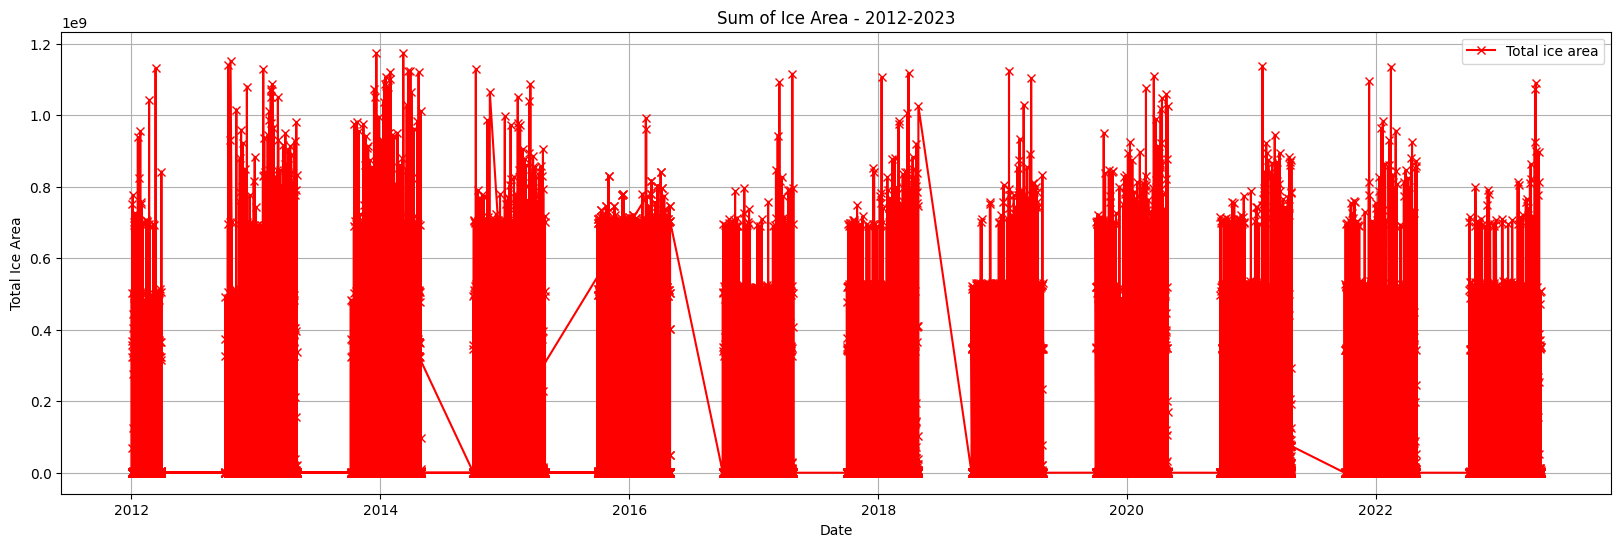

In [10]:
# Plot the results
plt.figure(figsize=(20, 6))
plt.plot(winter['date'], winter['area'], c= 'red', marker='x', label='Total ice area')
# plt.plot(dates, sums, marker='o', label='Total ice area')
plt.xlabel('Date')
plt.ylabel('Total Ice Area')
# plt.ylim(0,1.3e6)
plt.title('Sum of Ice Area - 2012-2023')
plt.legend()
plt.grid()
plt.show()

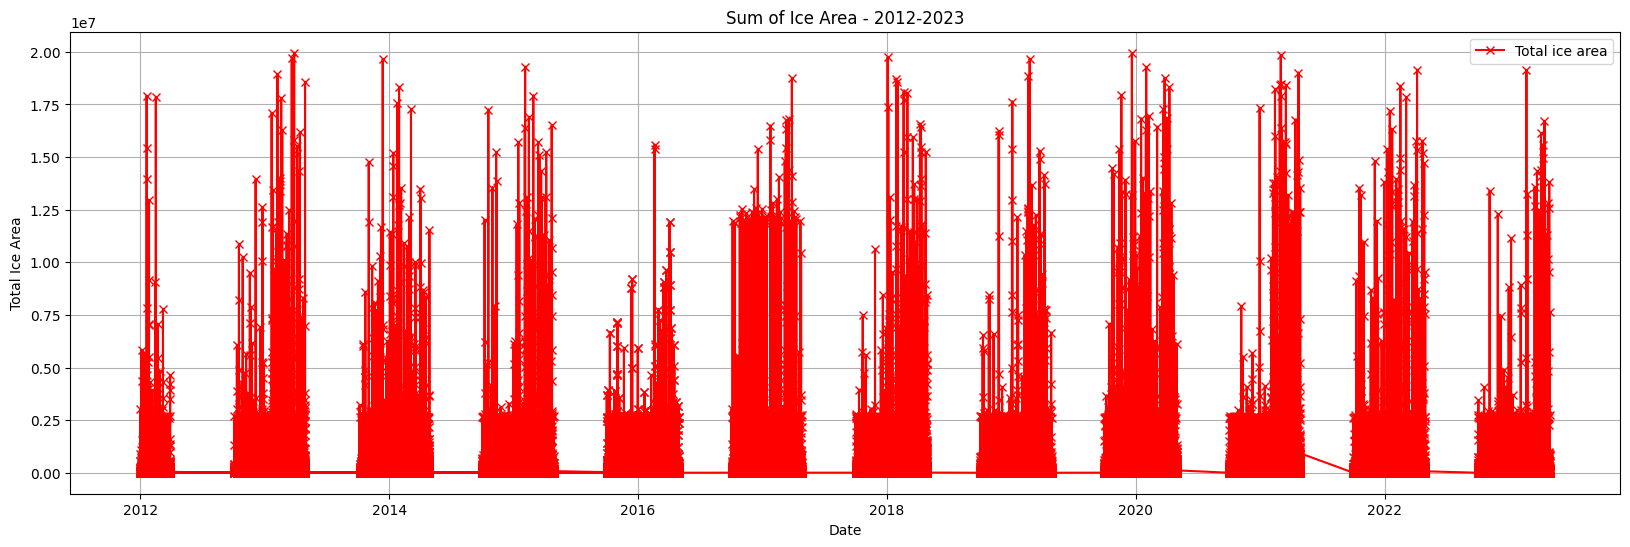

In [11]:
# Plot the results
plt.figure(figsize=(20, 6))
plt.plot(rsw['date'], rsw['area'], c= 'red', marker='x', label='Total ice area')
# plt.plot(dates, sums, marker='o', label='Total ice area')
plt.xlabel('Date')
plt.ylabel('Total Ice Area')
# plt.ylim(0,1.3e6)
plt.title('Sum of Ice Area - 2012-2023')
plt.legend()
plt.grid()
plt.show()

In [11]:
result = rsw.groupby(['date', 'value'])['area'].sum().reset_index()
print(result)

           date  value         area
0    2012-01-02    0.0  707585000.0
1    2012-01-02    1.0  504175000.0
2    2012-01-03    0.0  775367500.0
3    2012-01-03    1.0  436392500.0
4    2012-01-05    0.0  793070000.0
...         ...    ...          ...
3077 2023-04-27    1.0  520365000.0
3078 2023-04-29    0.0  729220000.0
3079 2023-04-29    1.0  506382500.0
3080 2023-04-30    0.0  717932500.0
3081 2023-04-30    1.0  517670000.0

[3082 rows x 3 columns]


In [12]:
ice_area = result[result['value'] == 1] 
print(ice_area)

           date  value         area
1    2012-01-02    1.0  504175000.0
3    2012-01-03    1.0  436392500.0
5    2012-01-05    1.0  418690000.0
7    2012-01-06    1.0  423730000.0
9    2012-01-09    1.0  495280000.0
...         ...    ...          ...
3073 2023-04-24    1.0  327082500.0
3075 2023-04-25    1.0  412230000.0
3077 2023-04-27    1.0  520365000.0
3079 2023-04-29    1.0  506382500.0
3081 2023-04-30    1.0  517670000.0

[1541 rows x 3 columns]


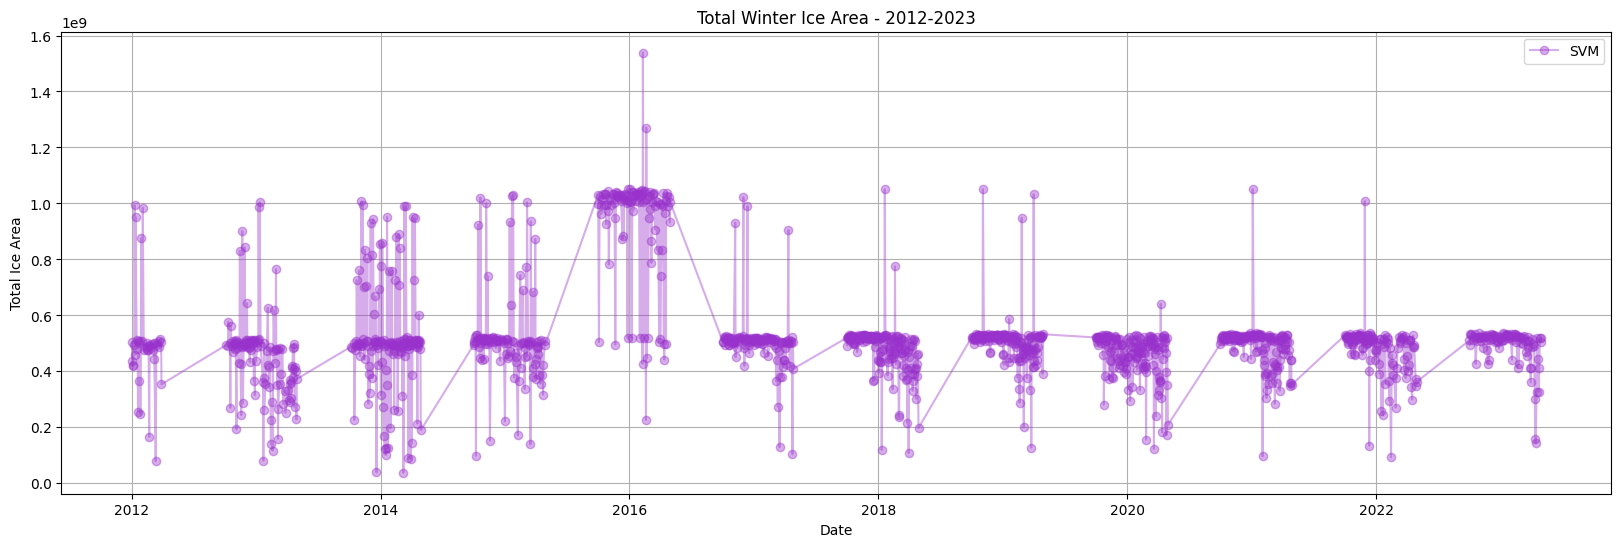

In [13]:
# Plot the results
plt.figure(figsize=(20, 6))
plt.plot(ice_area['date'], ice_area['area'], c='darkorchid', marker='o', alpha=0.4, label='SVM')
plt.xlabel('Date')
plt.ylabel('Total Ice Area')
# plt.ylim(0,1.3e6)
plt.title('Total Winter Ice Area - 2012-2023')
plt.legend()
plt.grid()
# plt.savefig("C:/Users/jullian.williams/Desktop/plots.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.show()

## Summer

In [14]:
input_dir = "C:/Users/jullian.williams/Desktop/plots/RS_Summer/"

dataframes_rs = []

# Loop through all .tif files in the input directory
for subdir, _, files in os.walk(input_dir):
    for filename in files: 
        # Check if the file is an image (e.g., .jpg, .png)
        if filename.endswith(('.tif')):
            input_path = os.path.join(subdir, filename)
             
            with rio.open(input_path) as src_:
                profile = src_.profile  # Save metadata
                transform_ = src_.transform
                crs_=src_.crs
                b1_ = src_.read(1)
                
                def image_to_geodataframe(image_array, transform, crs):
            # Generate shapes (polygons) from the raster array
                    shapes_generator = shapes(image_array, transform=transform_)
                    
                    # Create a GeoDataFrame
                    geometries = []
                    values = []
                    for geom, value in shapes_generator:
                        geometries.append(shape(geom))
                        values.append(value)

                        name, ext = os.path.splitext(filename)
                        raftposition = 17
                        bfposition = 9
                
                        # Create the new file name
                        file_name = f"{filename[:raftposition]}"
                        fname = f"{file_name[bfposition:]}"
                                
                            
                    gdf = gpd.GeoDataFrame({'value': values, 'geometry': geometries, 'date':fname}, crs=crs_)
                    
                    return gdf 
                    
            gdf = image_to_geodataframe(b1_, transform=transform_, crs=crs_)


            gdf['date'] = pd.to_datetime(gdf['date'])
            gdf['area'] = gdf.geometry.area
            gdf['perimeter'] = gdf.geometry.length
            gdf['centroid'] = gdf.geometry.centroid
            # Extract latitude and longitude from centroids
            gdf['longitude'] = gdf.centroid.x
            gdf['latitude'] = gdf.centroid.y
            gdf.set_crs(epsg=32633, inplace=True)

            dataframes_rs.append(gdf)

In [15]:
input_dir = "C:/Users/jullian.williams/Desktop/EW_Summer/"

dataframes_ew = []

# Loop through all .tif files in the input directory
for subdir, _, files in os.walk(input_dir):
    for filename in files: 
        # Check if the file is an image (e.g., .jpg, .png)
        if filename.endswith(('.tif')):
            input_path = os.path.join(subdir, filename)
             
            with rio.open(input_path) as src_:
                profile = src_.profile  # Save metadata
                transform_ = src_.transform
                crs_=src_.crs
                b1_ = src_.read(1)
                
                def image_to_geodataframe(image_array, transform, crs):
            # Generate shapes (polygons) from the raster array
                    shapes_generator = shapes(image_array, transform=transform_)
                    
                    # Create a GeoDataFrame
                    geometries = []
                    values = []
                    for geom, value in shapes_generator:
                        geometries.append(shape(geom))
                        values.append(value)

                        name, ext = os.path.splitext(filename)
                        raftposition = 15
                        bfposition = 7
                
                        # Create the new file name
                        file_name = f"{filename[:raftposition]}"
                        fname = f"{file_name[bfposition:]}"
                                
                            
                    gdf = gpd.GeoDataFrame({'value': values, 'geometry': geometries, 'date':fname}, crs=crs_)
                    
                    return gdf 
                    
            gdf = image_to_geodataframe(b1_, transform=transform_, crs=crs_)


            gdf['date'] = pd.to_datetime(gdf['date'])
            gdf['area'] = gdf.geometry.area
            gdf['perimeter'] = gdf.geometry.length
            gdf['centroid'] = gdf.geometry.centroid
            # Extract latitude and longitude from centroids
            gdf['longitude'] = gdf.centroid.x
            gdf['latitude'] = gdf.centroid.y
            gdf.set_crs(epsg=32633, inplace=True)

            dataframes_ew.append(gdf)

In [16]:
input_dir = "C:/Users/jullian.williams/Desktop/EW_summer2/"

dataframes_ew_ = []

# Loop through all .tif files in the input directory
for subdir, _, files in os.walk(input_dir):
    for filename in files: 
        # Check if the file is an image (e.g., .jpg, .png)
        if filename.endswith(('.tif')):
            input_path = os.path.join(subdir, filename)
             
            with rio.open(input_path) as src_:
                profile = src_.profile  # Save metadata
                transform_ = src_.transform
                crs_=src_.crs
                b1_ = src_.read(1)
                
                def image_to_geodataframe(image_array, transform, crs):
            # Generate shapes (polygons) from the raster array
                    shapes_generator = shapes(image_array, transform=transform_)
                    
                    # Create a GeoDataFrame
                    geometries = []
                    values = []
                    for geom, value in shapes_generator:
                        geometries.append(shape(geom))
                        values.append(value)

                        name, ext = os.path.splitext(filename)
                        raftposition = 15
                        bfposition = 7
                
                        # Create the new file name
                        file_name = f"{filename[:raftposition]}"
                        fname = f"{file_name[bfposition:]}"
                                
                            
                    gdf = gpd.GeoDataFrame({'value': values, 'geometry': geometries, 'date':fname}, crs=crs_)
                    
                    return gdf 
                    
            gdf = image_to_geodataframe(b1_, transform=transform_, crs=crs_)


            gdf['date'] = pd.to_datetime(gdf['date'])
            gdf['area'] = gdf.geometry.area
            gdf['perimeter'] = gdf.geometry.length
            gdf['centroid'] = gdf.geometry.centroid
            # Extract latitude and longitude from centroids
            gdf['longitude'] = gdf.centroid.x
            gdf['latitude'] = gdf.centroid.y
            gdf.set_crs(epsg=32633, inplace=True)

            dataframes_ew_.append(gdf)

In [17]:
rssummer = pd.concat(dataframes_rs, ignore_index=True)
print(rssummer)

        value                                           geometry       date  \
0         1.0  POLYGON ((498975 8559025, 498975 8558875, 4990... 2012-05-06   
1         1.0  POLYGON ((499475 8559025, 499475 8558975, 4993... 2012-05-06   
2         1.0  POLYGON ((499675 8558775, 499675 8558725, 4997... 2012-05-06   
3         1.0  POLYGON ((499175 8558675, 499175 8558625, 4992... 2012-05-06   
4         1.0  POLYGON ((500825 8558275, 500825 8558225, 5007... 2012-05-06   
...       ...                                                ...        ...   
624020    1.0  POLYGON ((501875 8531075, 501875 8531025, 5019... 2014-09-30   
624021    0.0  POLYGON ((498975 8559025, 498975 8558075, 4990... 2014-09-30   
624022    1.0  POLYGON ((503825 8531075, 503825 8531025, 5039... 2014-09-30   
624023    1.0  POLYGON ((507175 8531075, 507175 8531025, 5072... 2014-09-30   
624024    1.0  POLYGON ((513125 8531125, 513125 8531075, 5129... 2014-09-30   

                area  perimeter                    

In [18]:
ewsummer = pd.concat(dataframes_ew, ignore_index=True)
print(ewsummer)

        value                                           geometry       date  \
0         0.0  POLYGON ((499075 8559025, 499075 8558975, 4991... 2015-05-01   
1         0.0  POLYGON ((499975 8559025, 499975 8558975, 5000... 2015-05-01   
2         0.0  POLYGON ((500125 8559025, 500125 8558925, 5001... 2015-05-01   
3         0.0  POLYGON ((499475 8558975, 499475 8558925, 4995... 2015-05-01   
4         0.0  POLYGON ((499125 8558975, 499125 8558925, 4991... 2015-05-01   
...       ...                                                ...        ...   
267032    1.0  POLYGON ((498975 8559025, 498975 8556825, 4990... 2016-09-30   
267033    0.0  POLYGON ((511125 8531025, 511125 8530975, 5111... 2016-09-30   
267034    0.0  POLYGON ((512675 8531025, 512675 8530975, 5127... 2016-09-30   
267035    1.0  POLYGON ((513925 8531125, 513925 8531075, 5139... 2016-09-30   
267036    1.0  POLYGON ((514375 8531275, 514375 8531125, 5144... 2016-09-30   

               area  perimeter                     

In [19]:
ewsummer_ = pd.concat(dataframes_ew_, ignore_index=True)
print(ewsummer_)

         value                                           geometry       date  \
0          0.0  POLYGON ((499075 8559025, 499075 8558975, 4991... 2015-05-01   
1          0.0  POLYGON ((499975 8559025, 499975 8558975, 5000... 2015-05-01   
2          0.0  POLYGON ((500125 8559025, 500125 8558925, 5001... 2015-05-01   
3          0.0  POLYGON ((499475 8558975, 499475 8558925, 4995... 2015-05-01   
4          0.0  POLYGON ((499125 8558975, 499125 8558925, 4991... 2015-05-01   
...        ...                                                ...        ...   
1262773    1.0  POLYGON ((512725 8532825, 512725 8532775, 5126... 2023-06-29   
1262774    1.0  POLYGON ((510625 8531125, 510625 8531075, 5105... 2023-06-29   
1262775    1.0  POLYGON ((510175 8531075, 510175 8531025, 5100... 2023-06-29   
1262776    0.0  POLYGON ((498975 8559025, 498975 8557375, 4990... 2023-06-29   
1262777    0.0  POLYGON ((498975 8559025, 498975 8546625, 5007... 2023-06-30   

                area  perimeter        

In [20]:
summer = pd.concat([rssummer,ewsummer,ewsummer_], ignore_index=True)
# print(summer)

In [19]:
# rss = summer.drop(summer[summer['area'] >= 2e7].index) # Remove wrapper cells
# print(rss)

         value                                           geometry       date  \
0          1.0  POLYGON ((498975 8559025, 498975 8558875, 4990... 2012-05-06   
1          1.0  POLYGON ((499475 8559025, 499475 8558975, 4993... 2012-05-06   
2          1.0  POLYGON ((499675 8558775, 499675 8558725, 4997... 2012-05-06   
3          1.0  POLYGON ((499175 8558675, 499175 8558625, 4992... 2012-05-06   
4          1.0  POLYGON ((500825 8558275, 500825 8558225, 5007... 2012-05-06   
...        ...                                                ...        ...   
2153833    0.0  POLYGON ((512675 8531075, 512675 8531025, 5127... 2023-06-29   
2153834    1.0  POLYGON ((511475 8531275, 511475 8531225, 5114... 2023-06-29   
2153835    1.0  POLYGON ((512725 8532825, 512725 8532775, 5126... 2023-06-29   
2153836    1.0  POLYGON ((510625 8531125, 510625 8531075, 5105... 2023-06-29   
2153837    1.0  POLYGON ((510175 8531075, 510175 8531025, 5100... 2023-06-29   

             area  perimeter           

In [21]:
rss = summer

C:\Users\jullian.williams\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


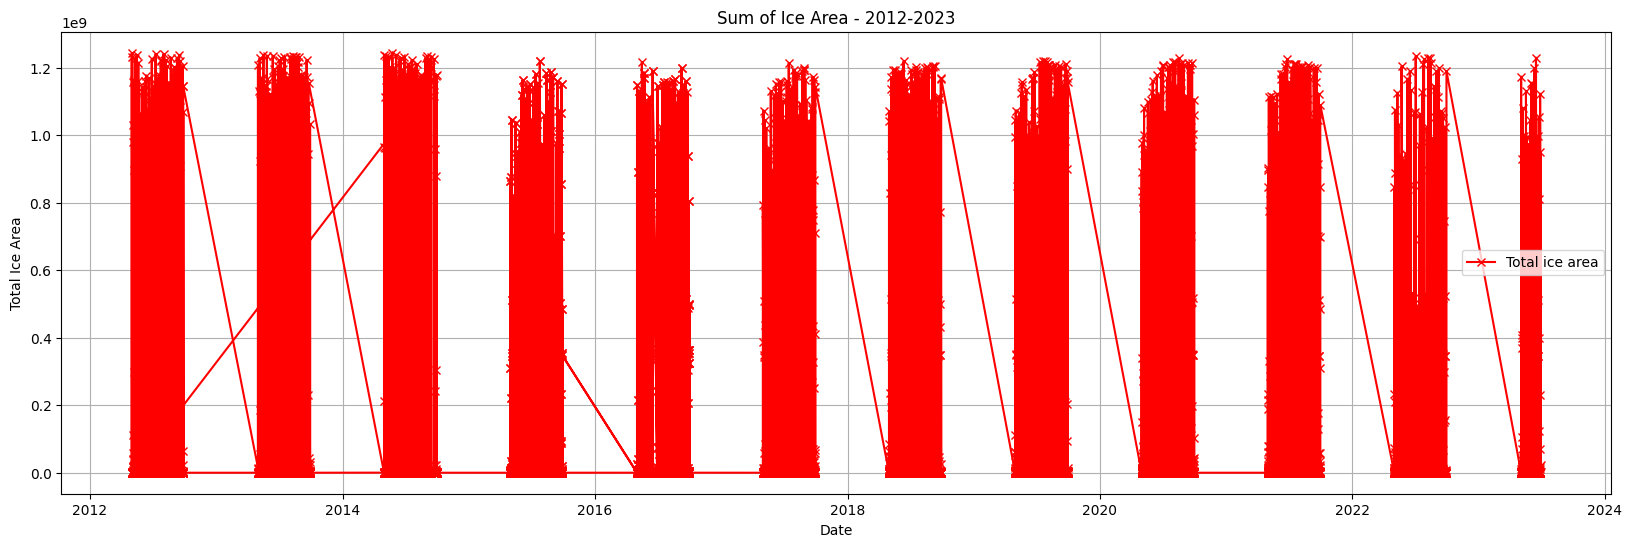

In [24]:
# Plot the results
plt.figure(figsize=(20, 6))
plt.plot(summer['date'], summer['area'], c= 'red', marker='x', label='Total ice area')
# plt.plot(dates, sums, marker='o', label='Total ice area')
plt.xlabel('Date')
plt.ylabel('Total Ice Area')
# plt.ylim(0,1.3e6)
plt.title('Sum of Ice Area - 2012-2023')
plt.legend()
plt.grid()
plt.show()

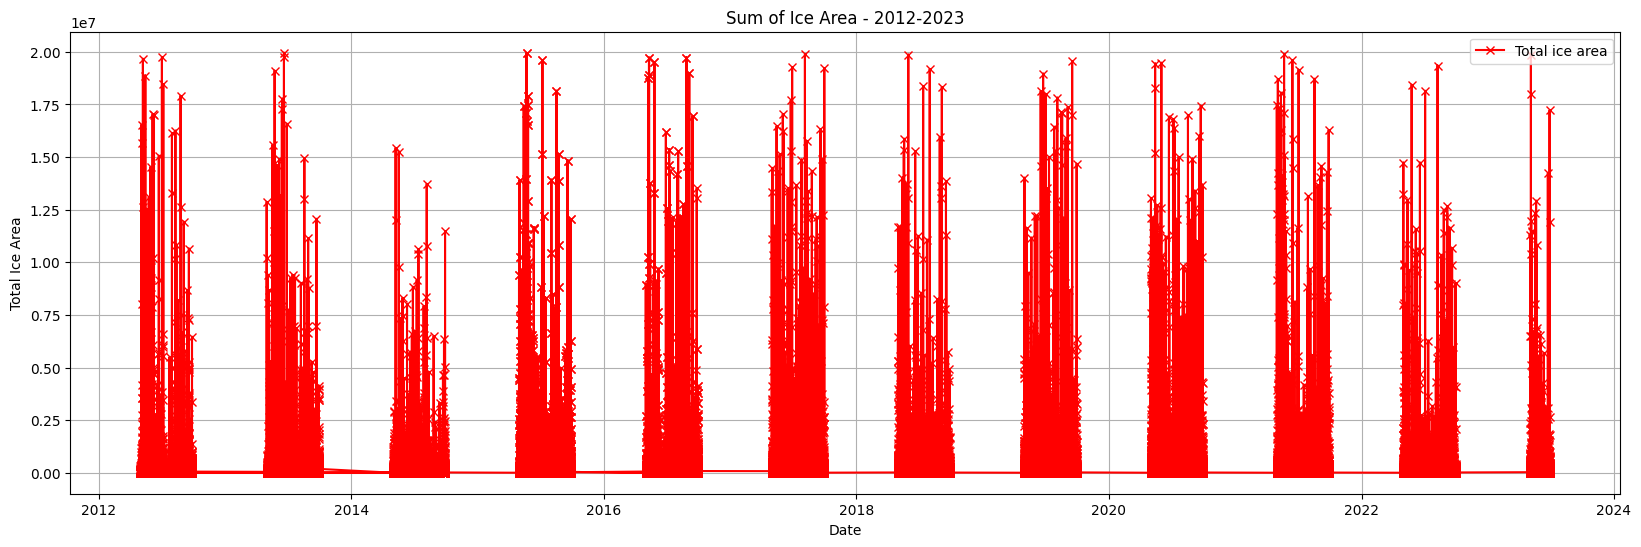

In [25]:
# Plot the results
plt.figure(figsize=(20, 6))
plt.plot(rss['date'], rss['area'], c= 'red', marker='x', label='Total ice area')
# plt.plot(dates, sums, marker='o', label='Total ice area')
plt.xlabel('Date')
plt.ylabel('Total Ice Area')
# plt.ylim(0,1.3e6)
plt.title('Sum of Ice Area - 2012-2023')
plt.legend()
plt.grid()
plt.show()

In [22]:
result_ = rss.groupby(['date', 'value'])['area'].sum().reset_index()
print(result_)

           date  value          area
0    2012-05-01    0.0  2.028500e+07
1    2012-05-01    1.0  1.243368e+09
2    2012-05-02    0.0  3.278000e+07
3    2012-05-02    1.0  1.230872e+09
4    2012-05-04    0.0  1.043345e+09
...         ...    ...           ...
2142 2023-06-28    0.0  1.129880e+09
2143 2023-06-28    1.0  9.691250e+07
2144 2023-06-29    0.0  9.528650e+08
2145 2023-06-29    1.0  2.827375e+08
2146 2023-06-30    0.0  2.232000e+07

[2147 rows x 3 columns]


In [23]:
ice_area_ = result_[result_['value'] == 1] 
print(ice_area_)

           date  value          area
1    2012-05-01    1.0  1.243368e+09
3    2012-05-02    1.0  1.230872e+09
5    2012-05-04    1.0  1.670125e+08
7    2012-05-06    1.0  2.113975e+08
9    2012-05-08    1.0  3.508900e+08
...         ...    ...           ...
2137 2023-06-23    1.0  2.032500e+06
2139 2023-06-24    1.0  1.575250e+08
2141 2023-06-26    1.0  4.115300e+08
2143 2023-06-28    1.0  9.691250e+07
2145 2023-06-29    1.0  2.827375e+08

[1073 rows x 3 columns]


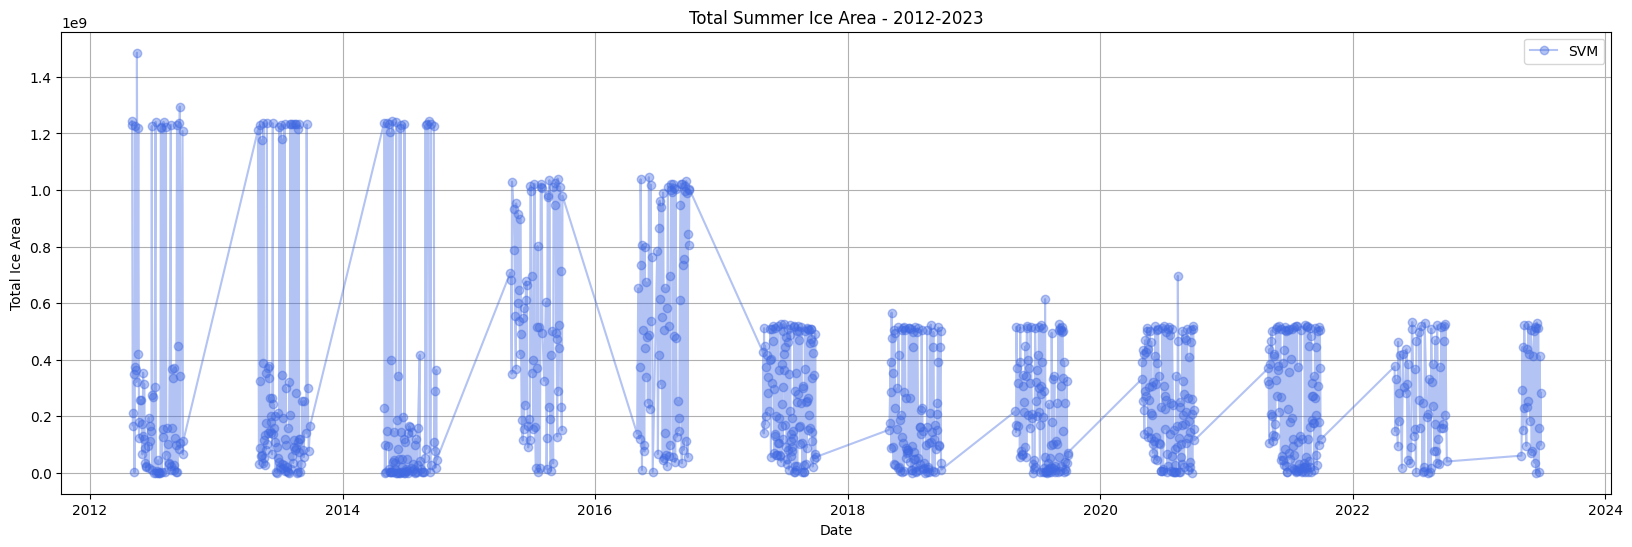

In [24]:
# Plot the results
plt.figure(figsize=(20, 6))
plt.plot(ice_area_['date'], ice_area_['area'], c='royalblue', marker='o', alpha=0.4, label='SVM')
plt.xlabel('Date')
plt.ylabel('Total Ice Area')
# plt.ylim(0,1.3e6)
plt.title('Total Summer Ice Area - 2012-2023')
plt.legend()
plt.grid()
# plt.savefig("C:/Users/jullian.williams/Desktop/plots.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.show()

# All seasons

## SVM

In [39]:
rs2 =  pd.concat([winter, summer], ignore_index=True)
print(rs2)

         value                                           geometry       date  \
0          0.0  POLYGON ((500275 8558875, 500275 8558825, 5003... 2012-02-03   
1          1.0  POLYGON ((500825 8558275, 500825 8558225, 5007... 2012-02-03   
2          1.0  POLYGON ((501175 8558075, 501175 8558025, 5010... 2012-02-03   
3          0.0  POLYGON ((499575 8557625, 499575 8557575, 4996... 2012-02-03   
4          0.0  POLYGON ((500575 8557575, 500575 8557525, 5006... 2012-02-03   
...        ...                                                ...        ...   
5352236    1.0  POLYGON ((512725 8532825, 512725 8532775, 5126... 2023-06-29   
5352237    1.0  POLYGON ((510625 8531125, 510625 8531075, 5105... 2023-06-29   
5352238    1.0  POLYGON ((510175 8531075, 510175 8531025, 5100... 2023-06-29   
5352239    0.0  POLYGON ((498975 8559025, 498975 8557375, 4990... 2023-06-29   
5352240    0.0  POLYGON ((498975 8559025, 498975 8546625, 5007... 2023-06-30   

                area  perimeter        

In [40]:
rs2 = rs2.drop(rs2[rs2['area'] >= 2e7].index) # Remove wrapper cells
print(rs2)

         value                                           geometry       date  \
0          0.0  POLYGON ((500275 8558875, 500275 8558825, 5003... 2012-02-03   
1          1.0  POLYGON ((500825 8558275, 500825 8558225, 5007... 2012-02-03   
2          1.0  POLYGON ((501175 8558075, 501175 8558025, 5010... 2012-02-03   
3          0.0  POLYGON ((499575 8557625, 499575 8557575, 4996... 2012-02-03   
4          0.0  POLYGON ((500575 8557575, 500575 8557525, 5006... 2012-02-03   
...        ...                                                ...        ...   
5352234    0.0  POLYGON ((512675 8531075, 512675 8531025, 5127... 2023-06-29   
5352235    1.0  POLYGON ((511475 8531275, 511475 8531225, 5114... 2023-06-29   
5352236    1.0  POLYGON ((512725 8532825, 512725 8532775, 5126... 2023-06-29   
5352237    1.0  POLYGON ((510625 8531125, 510625 8531075, 5105... 2023-06-29   
5352238    1.0  POLYGON ((510175 8531075, 510175 8531025, 5100... 2023-06-29   

             area  perimeter           

In [41]:
rt = rs2.groupby(['date', 'value'])['area'].sum().reset_index()
print(rt)

           date  value        area
0    2012-01-02    0.0  14067500.0
1    2012-01-02    1.0   1140000.0
2    2012-01-03    0.0  24877500.0
3    2012-01-03    1.0   7987500.0
4    2012-01-05    0.0  17307500.0
...         ...    ...         ...
5188 2023-06-26    1.0  12077500.0
5189 2023-06-28    0.0   6107500.0
5190 2023-06-28    1.0  25240000.0
5191 2023-06-29    0.0   3215000.0
5192 2023-06-29    1.0  52542500.0

[5193 rows x 3 columns]


In [42]:
iceara = rt[rt['value'] == 1] 
print(iceara)

           date  value        area
1    2012-01-02    1.0   1140000.0
3    2012-01-03    1.0   7987500.0
5    2012-01-05    1.0  16722500.0
7    2012-01-06    1.0  18317500.0
9    2012-01-09    1.0   1452500.0
...         ...    ...         ...
5184 2023-06-23    1.0   2032500.0
5186 2023-06-24    1.0  33812500.0
5188 2023-06-26    1.0  12077500.0
5190 2023-06-28    1.0  25240000.0
5192 2023-06-29    1.0  52542500.0

[2589 rows x 3 columns]


In [43]:
r = rs2.groupby(['date'])['area'].sum().reset_index()
print(r)

           date        area
0    2012-01-02  15207500.0
1    2012-01-03  32865000.0
2    2012-01-05  34030000.0
3    2012-01-06  27402500.0
4    2012-01-09  17010000.0
...         ...         ...
2609 2023-06-23   2060000.0
2610 2023-06-24  47815000.0
2611 2023-06-26  25960000.0
2612 2023-06-28  31347500.0
2613 2023-06-29  55757500.0

[2614 rows x 2 columns]


In [47]:
xm = pd.merge(iceara,r, on='date',how='outer').fillna(0)
xm['perc'] = (xm['area_x']/xm['area_y'])*100
xm['julian'] = xm['date'].dt.strftime('%j')
print(xm)

           date  value      area_x      area_y       perc julian
0    2012-01-02    1.0   1140000.0  15207500.0   7.496301    002
1    2012-01-03    1.0   7987500.0  32865000.0  24.303971    003
2    2012-01-05    1.0  16722500.0  34030000.0  49.140464    005
3    2012-01-06    1.0  18317500.0  27402500.0  66.846091    006
4    2012-01-09    1.0   1452500.0  17010000.0   8.539095    009
...         ...    ...         ...         ...        ...    ...
2609 2023-06-23    1.0   2032500.0   2060000.0  98.665049    174
2610 2023-06-24    1.0  33812500.0  47815000.0  70.715257    175
2611 2023-06-26    1.0  12077500.0  25960000.0  46.523498    177
2612 2023-06-28    1.0  25240000.0  31347500.0  80.516788    179
2613 2023-06-29    1.0  52542500.0  55757500.0  94.233960    180

[2614 rows x 6 columns]


In [ ]:
# xm = pd.merge(iceara,r, on='date',how='outer').fillna(0)
# xm['perc'] = (xm['area_x']/532932708)*100
# xm['julian'] = xm['date'].dt.strftime('%j')
# print(xm)

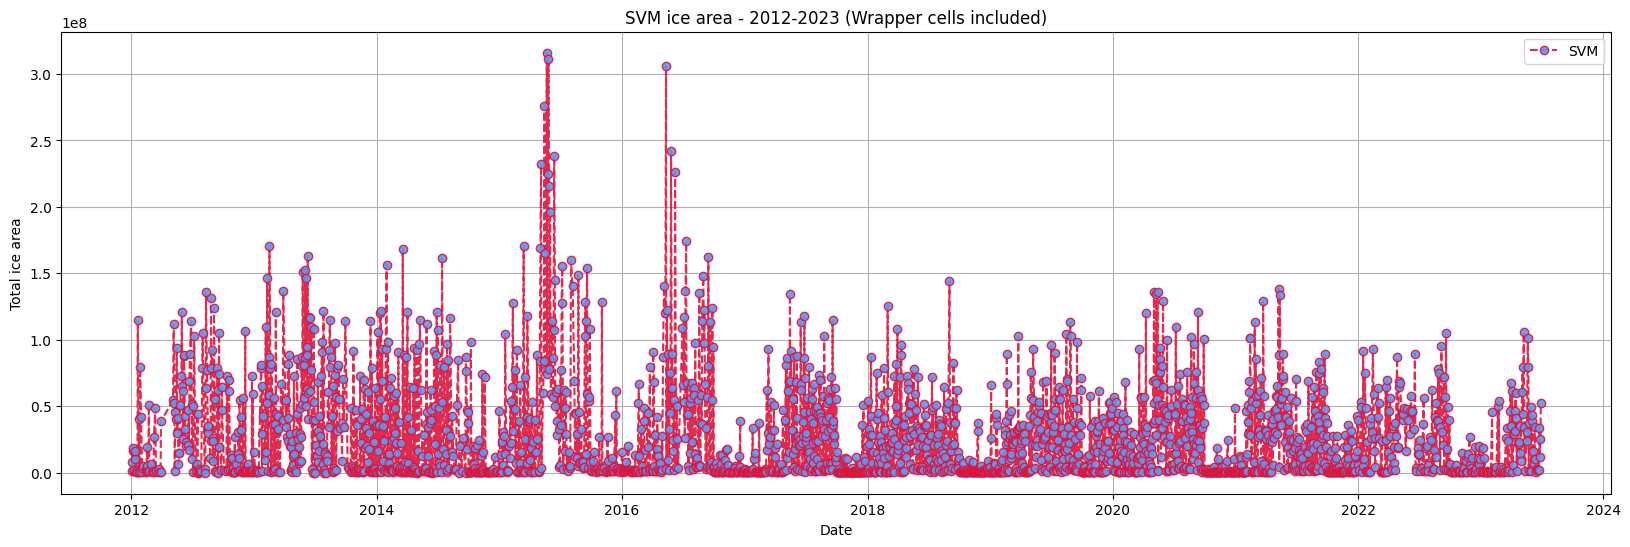

In [35]:
# Plot the results
plt.figure(figsize=(20, 6))
plt.plot(iceara['date'], iceara['area'], c='crimson', linestyle='--',markerfacecolor='cornflowerblue', marker='o', alpha=0.9, label='SVM')
plt.xlabel('Date')
plt.ylabel('Total ice area')
# plt.ylim(0,1.3e6)
plt.title('SVM ice area - 2012-2023 (Wrapper cells included)')
plt.legend()
plt.grid()
# plt.savefig("C:/Users/jullian.williams/Desktop/plots.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.show()

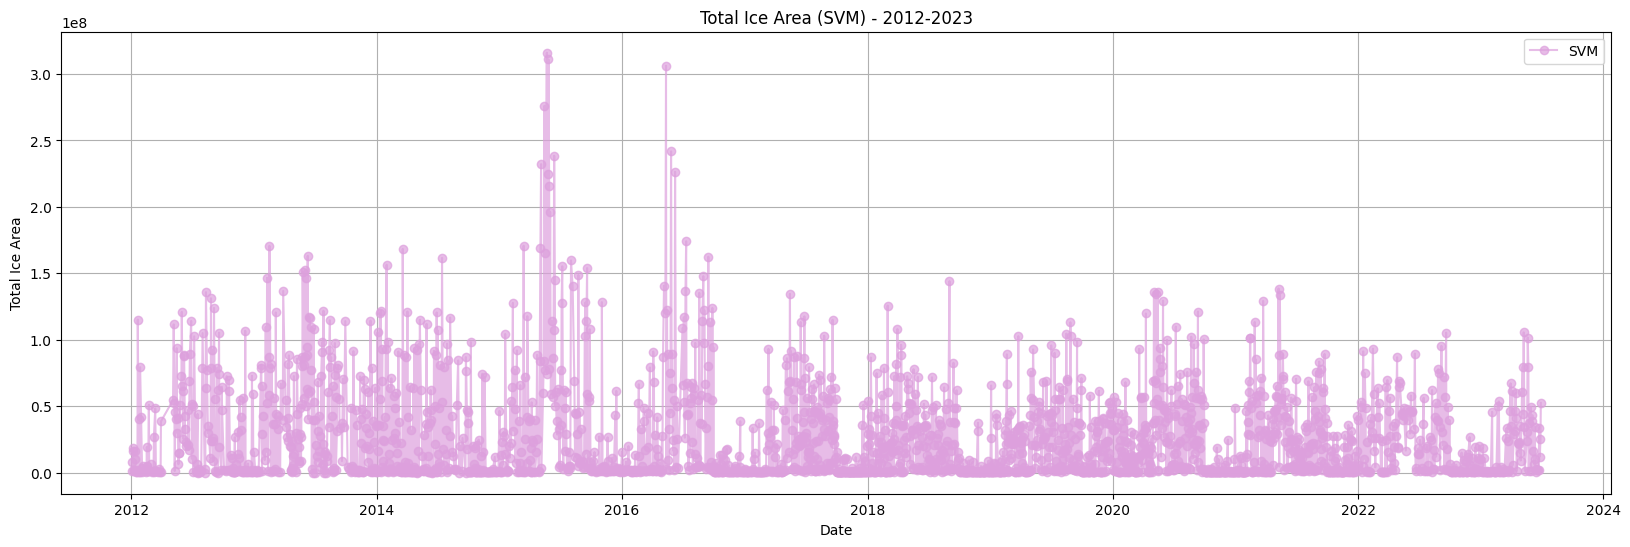

In [36]:
# Plot the results
plt.figure(figsize=(20, 6))
plt.plot(iceara['date'], iceara['area'], c='plum', marker='o', alpha=0.7, label='SVM')
plt.xlabel('Date')
plt.ylabel('Total Ice Area')
# start_date = datetime(2012, 1, 1)
# end_date = datetime(2016, 12, 31)
# plt.xlim(start_date, end_date)
# plt.ylim(0,1.3e6)
plt.title('Total Ice Area (SVM) - 2012-2023')
plt.legend()
plt.grid()
# plt.savefig("C:/Users/jullian.williams/Desktop/plots12_16.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.show()

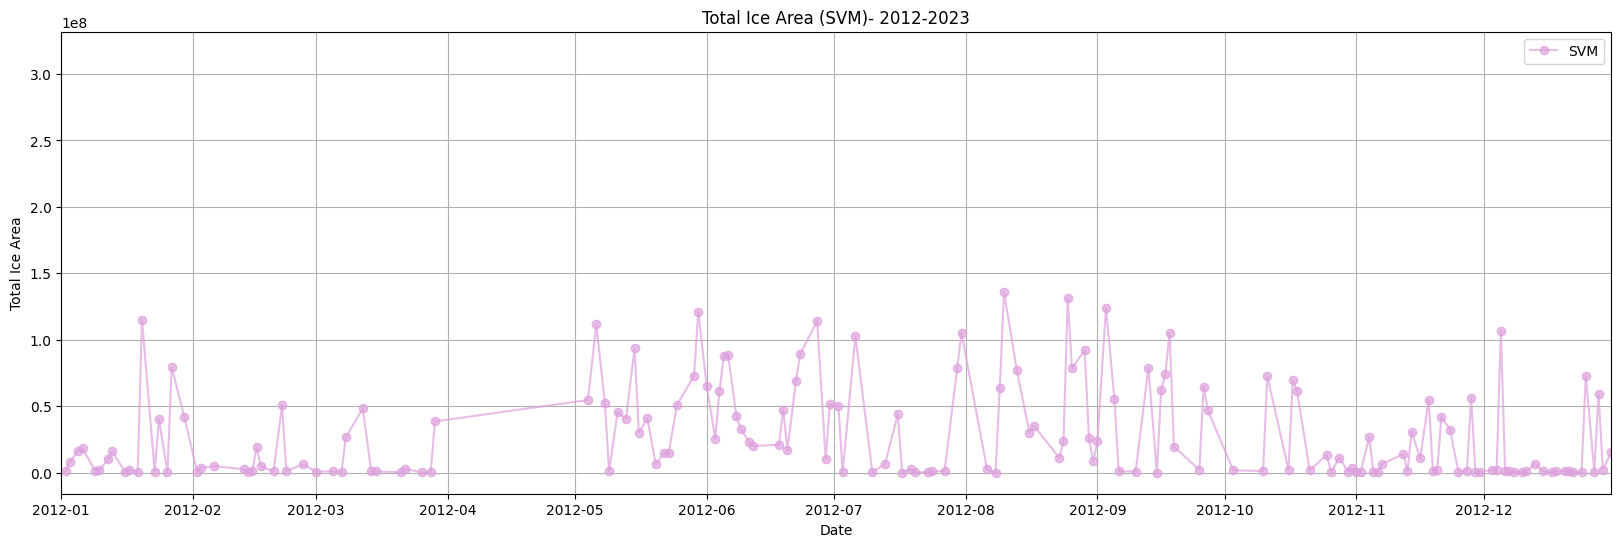

In [46]:
# Plot the results
plt.figure(figsize=(20, 6))
plt.plot(iceara['date'], iceara['area'], c='plum', marker='o', alpha=0.7, label='SVM')
plt.xlabel('Date')
plt.ylabel('Total Ice Area')
# start_date = datetime(2012, 1, 1)
# end_date = datetime(2012, 12, 31)
# plt.xlim(start_date, end_date)
# plt.ylim(0,1.3e6)
plt.title('Total Ice Area (SVM)- 2012-2023')
plt.legend()
plt.grid()
# plt.savefig("C:/Users/jullian.williams/Desktop/plots/2012_2023/TICESVM_12_23.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.show()

C:\Users\jullian.williams\AppData\Local\Temp\ipykernel_15592\2503379071.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


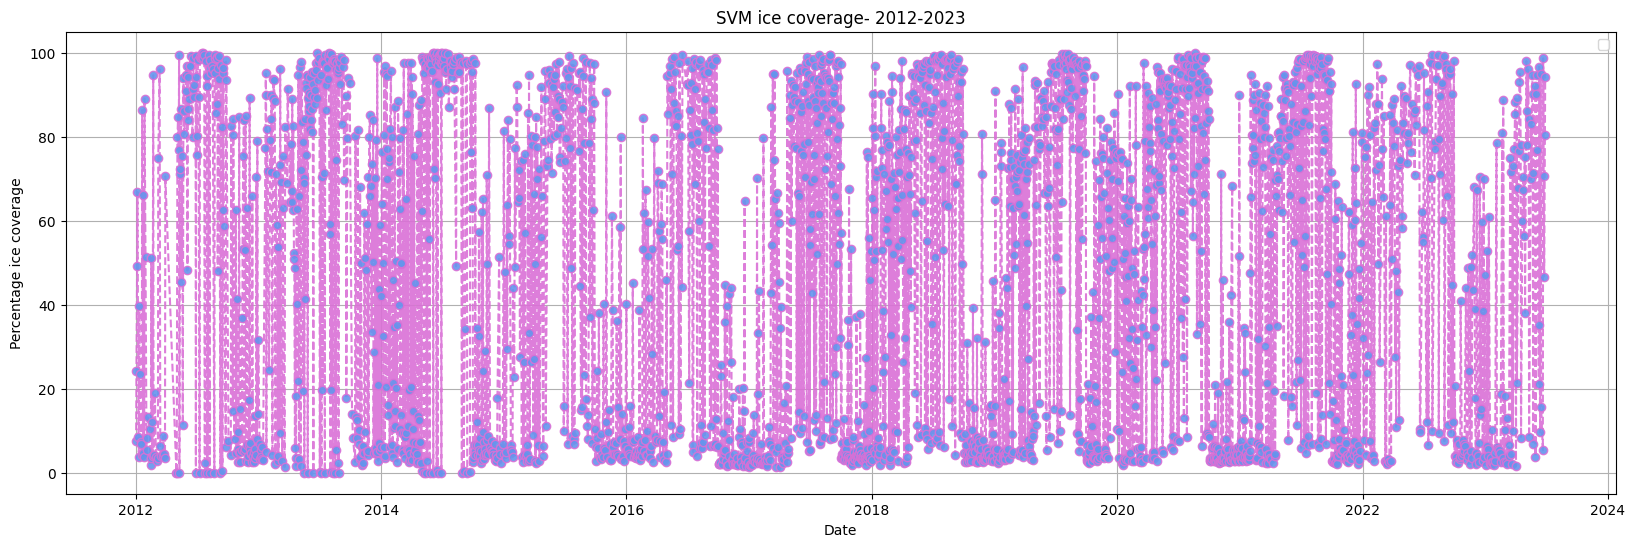

In [49]:
# Plot the results
plt.figure(figsize=(20, 6))
plt.plot(xm['date'], xm['perc'], c='orchid', linestyle='--', marker='o',markerfacecolor='cornflowerblue', alpha=0.9)
plt.xlabel('Date')
plt.ylabel('Percentage ice coverage')
# start_date = datetime(2012, 1, 1)
# end_date = datetime(2016, 12, 31) #(2015, 4, 30) 
# plt.xlim(start_date, end_date)
# plt.ylim(0,1.3e6)
plt.title('SVM ice coverage- 2012-2023')
plt.legend()
plt.grid()
# plt.savefig("C:/Users/jullian.williams/Desktop/plots/2012_2023/svmCOV2.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.show()

#### Linear regression

In [39]:
print(xm['perc'].dtype)

float64


In [50]:
r = rs2.groupby(['date'])['area'].mean().reset_index()
print(r)

           date          area
0    2012-01-02   7739.185751
1    2012-01-03   9465.725806
2    2012-01-05  10499.845727
3    2012-01-06  12865.023474
4    2012-01-09  10143.112701
...         ...           ...
2609 2023-06-23  29428.571429
2610 2023-06-24  34952.485380
2611 2023-06-26  11228.373702
2612 2023-06-28  27716.622458
2613 2023-06-29  67339.975845

[2614 rows x 2 columns]


In [51]:
xm = pd.merge(iceara,r, on='date',how='outer').fillna(0)
xm['julian'] = xm['date'].dt.strftime('%j')
print(xm)

           date  value      area_x        area_y julian
0    2012-01-02    1.0   1140000.0   7739.185751    002
1    2012-01-03    1.0   7987500.0   9465.725806    003
2    2012-01-05    1.0  16722500.0  10499.845727    005
3    2012-01-06    1.0  18317500.0  12865.023474    006
4    2012-01-09    1.0   1452500.0  10143.112701    009
...         ...    ...         ...           ...    ...
2609 2023-06-23    1.0   2032500.0  29428.571429    174
2610 2023-06-24    1.0  33812500.0  34952.485380    175
2611 2023-06-26    1.0  12077500.0  11228.373702    177
2612 2023-06-28    1.0  25240000.0  27716.622458    179
2613 2023-06-29    1.0  52542500.0  67339.975845    180

[2614 rows x 5 columns]


In [52]:
y = xm['area_y'].to_numpy()
stlist = xm['julian'].to_numpy()
x = [float(i) for i in stlist]
x = np.array(x)
print(x)

[  2.   3.   5. ... 177. 179. 180.]


In [53]:
def calc_linreg_coef(x,y):
    if(np.size(x) !=np.size(y)):
        sys.exit("Length of x and y are not the same")

    #Number of observations
    n = np.size(x)

    sx = np.sum(x)
    sy = np.sum(y)
    
    sx2 = np.inner(x,x)
    sxy = np.inner(x,y)
    sy2 = np.inner(y,y)

    #Calculation of regression coefficients
    a1 = (n*sxy - sx*sy)/(n*sx2 - sx**2)
    a0 = (sy/n) - (a1*sx)/n

    r2 = ((n*sxy-sx*sy)/np.sqrt(n*sx2-sx**2)/np.sqrt(n*sy2-sy**2))**2;
          
    return (a0, a1, r2)
        

In [54]:
a0, a1, r2 = calc_linreg_coef(x,y)

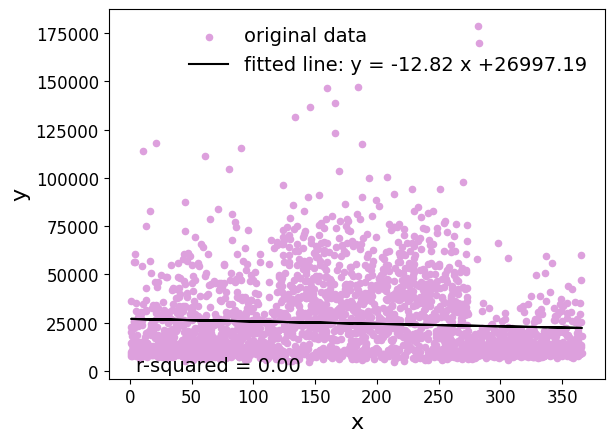

In [55]:
plt.scatter(x,y, c= 'plum', marker='o', s=20, label = 'original data')
y_pred = a0 + a1*x
plt.plot(x,y_pred, color = 'k', label = 'fitted line: y = %.2f x +%.2f'%(a1,a0)) 
plt.text(5,5,'r-squared = %.2f'%r2, fontsize = 14) 
plt.xlabel('x', fontsize = 16)
plt.ylabel('y', fontsize =16)
plt.tick_params(axis='both', which='major', labelsize = 12)
plt.legend(loc='upper right', fontsize = 14, frameon=False)
plt.show()

#### Correlations and Fourier Analysis

In [56]:
mty = (rt.groupby([rt['date'].dt.month,'value']))['area'].mean().unstack()
mty

value,0.0,1.0
date,,
1,1.779453e+07,1.653891e+07
2,1.797498e+07,2.297626e+07
3,1.755967e+07,2.450322e+07
4,1.606899e+07,2.174883e+07
5,1.246266e+07,5.808846e+07
6,1.006301e+07,3.977744e+07
7,1.074372e+07,3.070259e+07
8,9.875200e+06,3.617460e+07
9,1.421728e+07,3.911501e+07


In [57]:
icemty = (rt.groupby([rt['date'].dt.month,'value']))['area'].mean().unstack()
icemty

value,0.0,1.0
date,,
1,1.779453e+07,1.653891e+07
2,1.797498e+07,2.297626e+07
3,1.755967e+07,2.450322e+07
4,1.606899e+07,2.174883e+07
5,1.246266e+07,5.808846e+07
6,1.006301e+07,3.977744e+07
7,1.074372e+07,3.070259e+07
8,9.875200e+06,3.617460e+07
9,1.421728e+07,3.911501e+07


In [58]:
iceyrl = (rt.groupby([rt['date'].dt.year,'value']))['area'].mean().unstack()
iceyrl

value,0.0,1.0
date,,
2012,1.632837e+07,2.839604e+07
2013,1.779350e+07,3.981740e+07
2014,1.525021e+07,2.538970e+07
2015,2.178869e+07,4.415212e+07
2016,2.492989e+07,2.930891e+07
2017,1.366071e+07,1.929200e+07
2018,1.196406e+07,1.953556e+07
2019,1.142661e+07,2.191022e+07
2020,1.282000e+07,2.353168e+07


In [59]:
cormty = mty.corr()
corimty = icemty.corr()
coriyrl = iceyrl.corr()
cormty

value,0.0,1.0
value,,
0.0,1.000000,-0.737987
1.0,-0.737987,1.000000


In [60]:
corimty

value,0.0,1.0
value,,
0.0,1.000000,-0.737987
1.0,-0.737987,1.000000


In [61]:
coriyrl

value,0.0,1.0
value,,
0.0,1.000000,0.727169
1.0,0.727169,1.000000


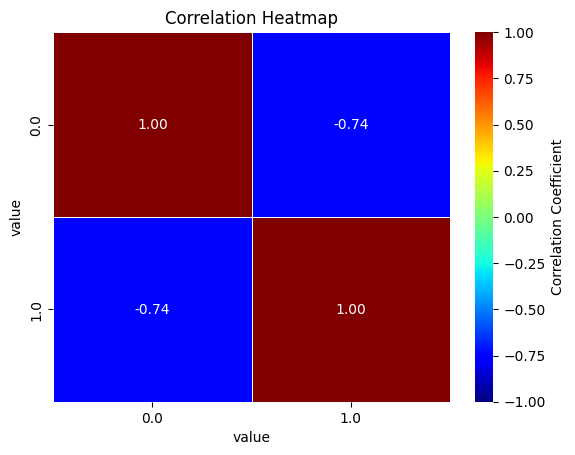

In [62]:
sns.heatmap(
    cormty, 
    annot=True, 
    fmt=".2f",  # Format for annotations:- decimal places
    cmap="jet",  # Custom color map
    linewidths=0.5,  # separation of blocks
    vmin = -1,
    vmax = 1,
    cbar_kws={'label': 'Correlation Coefficient'}  # Customize color bar
)
plt.title('Correlation Heatmap')
# plt.savefig("C:/Users/jullian.williams/Desktop/plots/2012_2023/svmcormty2.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.show()

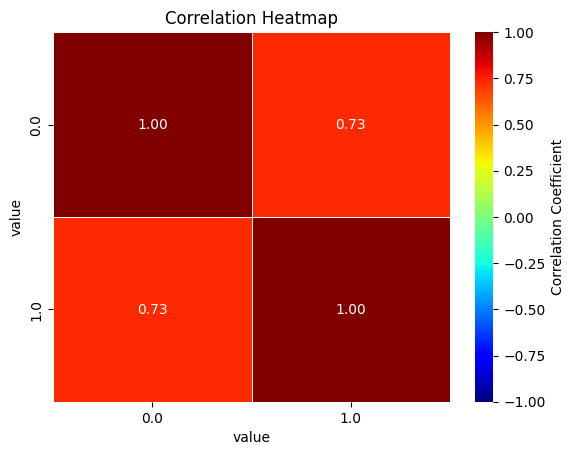

In [63]:
sns.heatmap(
    coriyrl, 
    annot=True, 
    fmt=".2f",  # Format for annotations:- decimal places
    cmap="jet",  # Custom color map
    linewidths=0.5,  # separation of blocks
    vmin = -1,
    vmax = 1,
    cbar_kws={'label': 'Correlation Coefficient'}  # Customize color bar
)
plt.title('Correlation Heatmap')
# plt.savefig("C:/Users/jullian.williams/Desktop/plots/2012_2023/svmcoriyrl2.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.show()

In [101]:
vt = (rs2.groupby([rs2['date'].dt.year,'value']))['area'].mean().unstack()

In [102]:
vt1 = vt[1]
vt1 = vt1.to_numpy()
vt1

array([ 78643.83448731,  90854.9369119 ,  74036.66116717, 132163.85867343,
        96833.99904663, 105899.77384868, 115327.66482367, 120939.5890831 ,
       116030.25643745, 121553.93283341, 134687.79840849, 132120.08442568])

In [103]:
vtft = fft(vt1)
vtft

array([1319092.39014693    -0.j        ,  -42100.34628005+86692.42771151j,
        -45633.45759105+58612.78303798j,  -32544.03442794+66914.88858821j,
         11987.74115326-13189.17508475j,  -35407.11030109-51607.31664334j,
        -87971.9614055     -0.j        ,  -35407.11030109+51607.31664334j,
         11987.74115326+13189.17508475j,  -32544.03442794-66914.88858821j,
        -45633.45759105-58612.78303798j,  -42100.34628005-86692.42771151j])

In [104]:
N = len(vtft)
n=np.arange(N)
sr=1/31556952 #placed in terms of seconds in year instead of # of years since hertz is in seconds but the plot looks virtually no different when run all the way through to the reconstruction plot
T = N/sr
freq = n/T

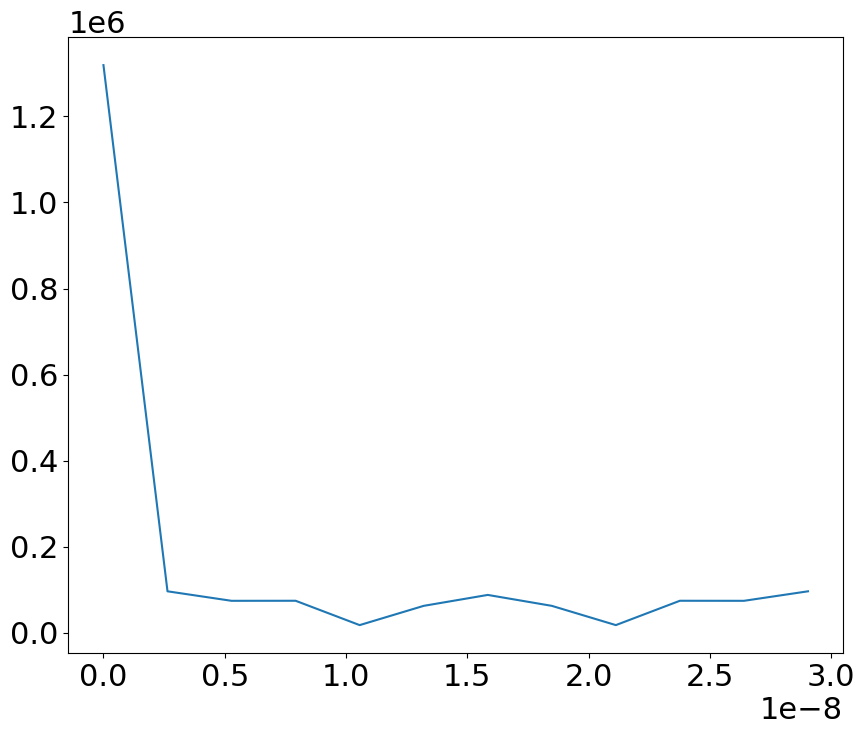

In [105]:
plt.figure(figsize=(10,8))
plt.plot(freq,np.abs(vtft)) #plot power spectrum as well

Text(0, 0.5, 'FFT amplitude')

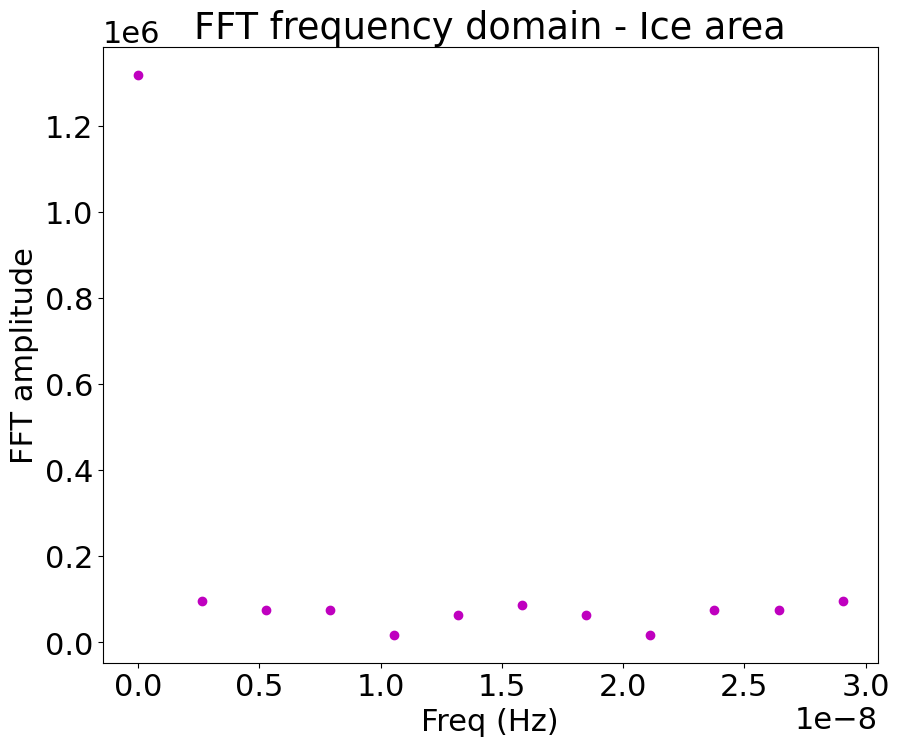

In [106]:
plt.figure(figsize=(10,8))
plt.plot(freq,np.abs(vtft),'mo') #plot power spectrum as well
plt.xlabel('Freq (Hz)')
plt.title('FFT frequency domain - Ice area')
plt.ylabel('FFT amplitude')

C:\Users\jullian.williams\AppData\Local\Temp\ipykernel_15592\511579271.py:11: RuntimeWarning: divide by zero encountered in divide
  np.allclose(peak_freq, 1./freq)


[]

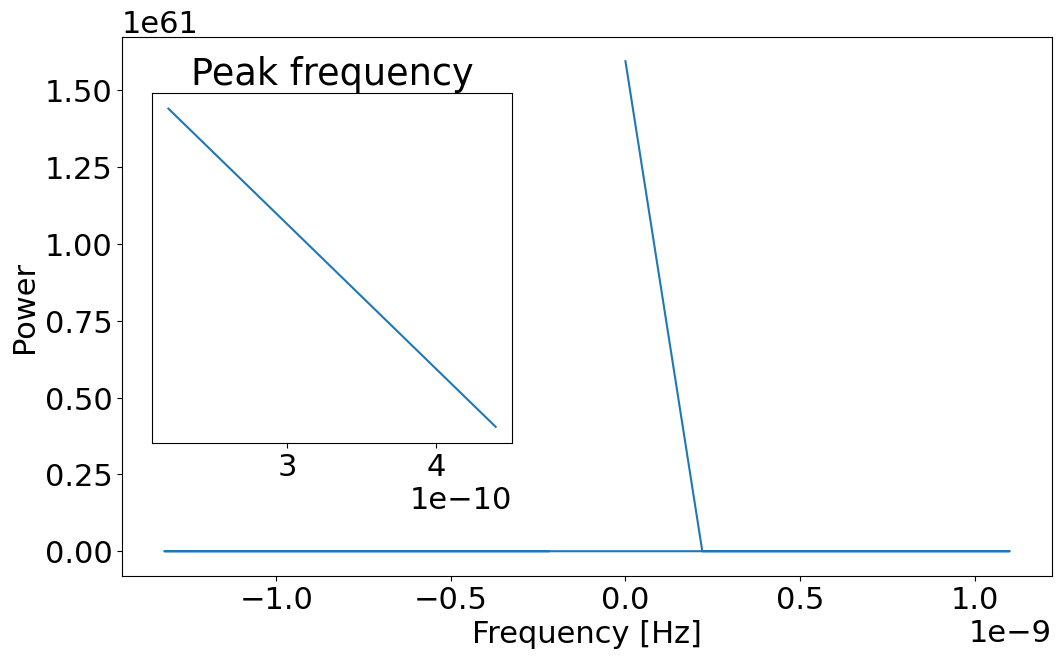

In [107]:
power = np.abs(vtft)**10
sample_freq = fftpack.fftfreq(vt1.size, d=T)
plt.figure(figsize=(12,7))
plt.plot(sample_freq, power)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')

pos_mask = np.where(sample_freq > 0)
freqs = sample_freq[pos_mask]
peak_freq = freqs[power[pos_mask].argmax()]
np.allclose(peak_freq, 1./freq)
axes = plt.axes([0.15, 0.3, 0.3, 0.5])
plt.title('Peak frequency')
plt.plot(freqs[:2], power[:2])
plt.setp(axes, yticks=[])

C:\Users\jullian.williams\.conda\envs\geospatial\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\jullian.williams\.conda\envs\geospatial\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


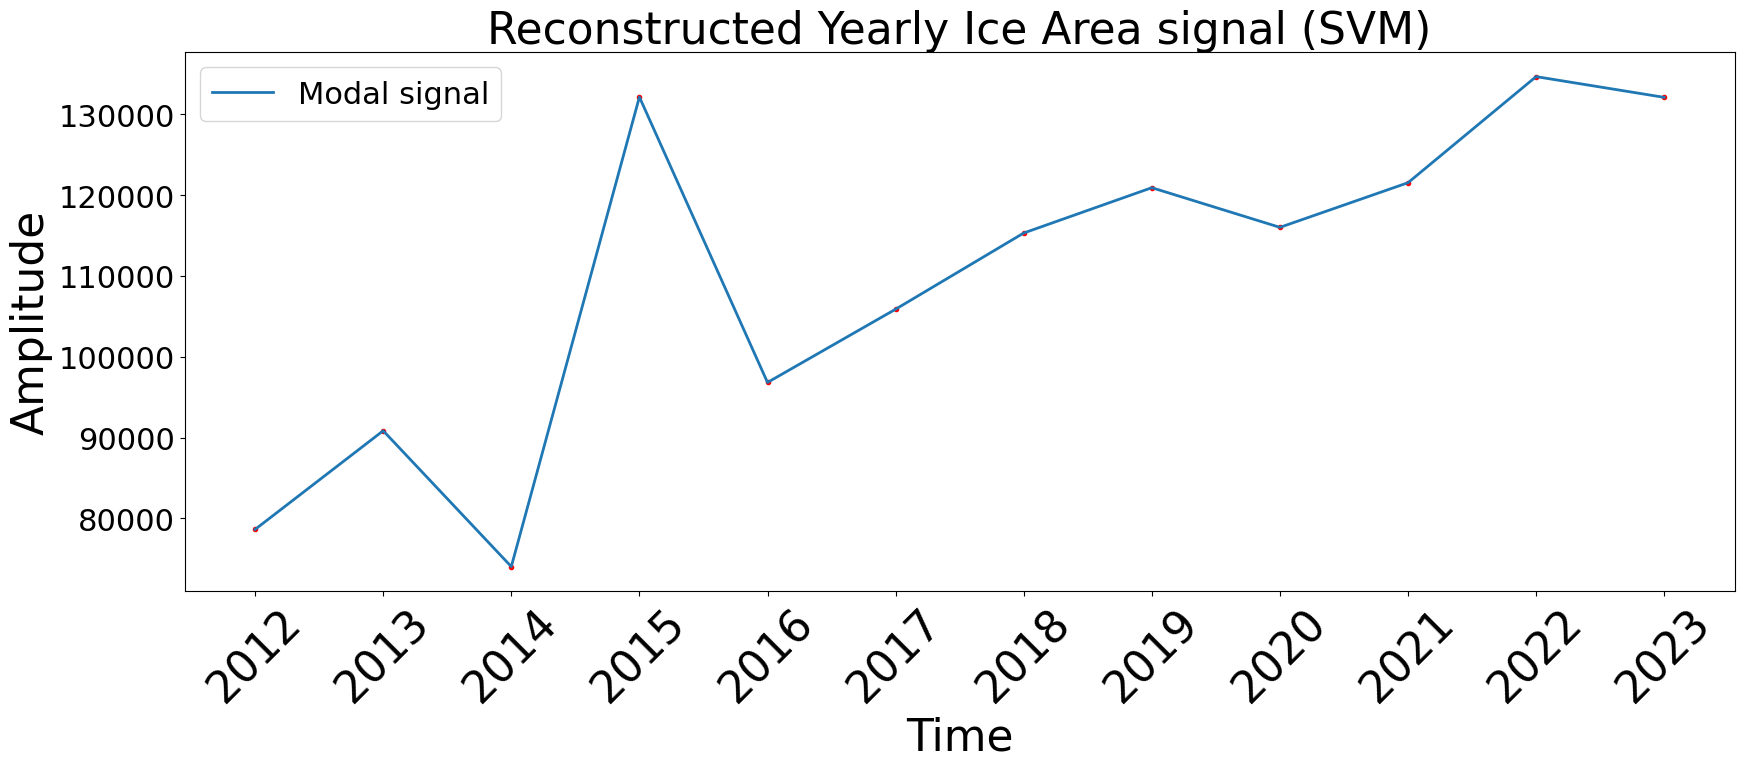

In [109]:
high_freq_fft = vtft.copy()
high_freq_fft[20::] = 0
filtered_sig = fftpack.ifft(high_freq_fft)

plt.figure(figsize=(20,7))
plt.plot(n, vt1, 'r.')
plt.plot(n, filtered_sig, linewidth=2, label= 'Modal signal')
plt.xticks(ticks=[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0], labels=['2012', '2013', '2014','2015', '2016', '2017', '2018', '2019','2020','2021','2022','2023'], rotation=45)
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Reconstructed Yearly Ice Area signal (SVM)')
# plt.savefig("C:/Users/jullian.williams/Desktop/plots/2012_2023/reconSVM2.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.legend(loc='best')

## Gaussian 

In [64]:
input_dir = "C:/Users/jullian.williams/Desktop/HIRLOMAP/binary_maps/"

df_ = []

# Loop through all .tif files in the input directory
for subdir, _, files in os.walk(input_dir):
    for filename in files: 
        # Check if the file is an image (e.g., .jpg, .png)
        if filename.endswith(('.tif')):
            input_path = os.path.join(subdir, filename)
             
            with rio.open(input_path) as src_:
                profile = src_.profile  # Save metadata
                transform_ = src_.transform
                crs_=src_.crs
                b1_ = src_.read(1)
                
                def image_to_geodataframe(image_array, transform, crs):
            # Generate shapes (polygons) from the raster array
                    shapes_generator = shapes(image_array, transform=transform_)
                    
                    # Create a GeoDataFrame
                    geometries = []
                    values = []
                    for geom, value in shapes_generator:
                        geometries.append(shape(geom))
                        values.append(value)
                        
                        name, ext = os.path.splitext(filename)
                        raftposition = 8
                    
                        # Create the new file name
                        file_name = f"{filename[:raftposition]}"
                                
                            
                    gdf = gpd.GeoDataFrame({'value': values, 'geometry': geometries, 'date':file_name}, crs=crs_)
                    
                    return gdf 
                    
            gdf = image_to_geodataframe(b1_, transform=transform_, crs=crs_)


            gdf['date'] = pd.to_datetime(gdf['date'])
            gdf['area'] = gdf.geometry.area
            gdf['perimeter'] = gdf.geometry.length
            gdf['centroid'] = gdf.geometry.centroid
            # Extract latitude and longitude from centroids
            gdf['longitude'] = gdf.centroid.x
            gdf['latitude'] = gdf.centroid.y
            gdf.set_crs(epsg=32633, inplace=True)

            df_.append(gdf)

In [65]:
rs2bin = pd.concat(df_, ignore_index=True)
print(rs2bin)

        value                                           geometry       date  \
0         1.0  POLYGON ((499625 8557925, 499625 8557875, 4995... 2012-01-02   
1         1.0  POLYGON ((522875 8557375, 522875 8557325, 5228... 2012-01-02   
2         1.0  POLYGON ((498975 8556975, 498975 8556825, 4990... 2012-01-02   
3         1.0  POLYGON ((523075 8556725, 523075 8556675, 5231... 2012-01-02   
4         1.0  POLYGON ((523175 8556675, 523175 8556625, 5232... 2012-01-02   
...       ...                                                ...        ...   
442488    0.0  POLYGON ((498975 8559025, 498975 8530975, 5440... 2023-06-26   
442489    0.0  POLYGON ((515425 8549275, 515425 8549125, 5153... 2023-06-28   
442490    1.0  POLYGON ((515625 8549625, 515625 8549575, 5154... 2023-06-28   
442491    0.0  POLYGON ((498975 8559025, 498975 8530975, 5440... 2023-06-28   
442492    0.0  POLYGON ((498975 8559025, 498975 8530975, 5440... 2023-06-29   

                area  perimeter                    

In [69]:
# rs2bin = rs2bin.drop(rs2bin[rs2bin['area'] >= 2e7].index) # Remove wrapper cells
# print(rs2bin)

        value                                           geometry       date  \
0         1.0  POLYGON ((499625 8557925, 499625 8557875, 4995... 2012-01-02   
1         1.0  POLYGON ((522875 8557375, 522875 8557325, 5228... 2012-01-02   
2         1.0  POLYGON ((498975 8556975, 498975 8556825, 4990... 2012-01-02   
3         1.0  POLYGON ((523075 8556725, 523075 8556675, 5231... 2012-01-02   
4         1.0  POLYGON ((523175 8556675, 523175 8556625, 5232... 2012-01-02   
...       ...                                                ...        ...   
442479    1.0  POLYGON ((513675 8531175, 513675 8531125, 5136... 2023-06-16   
442485    1.0  POLYGON ((515775 8548675, 515775 8548575, 5157... 2023-06-24   
442486    1.0  POLYGON ((516275 8548625, 516275 8548575, 5162... 2023-06-24   
442489    0.0  POLYGON ((515425 8549275, 515425 8549125, 5153... 2023-06-28   
442490    1.0  POLYGON ((515625 8549625, 515625 8549575, 5154... 2023-06-28   

             area  perimeter                       

In [66]:
rst = rs2bin.groupby(['date', 'value'])['area'].sum().reset_index()
print(rst)

           date  value          area
0    2012-01-02    0.0  1.260702e+09
1    2012-01-02    1.0  2.950000e+06
2    2012-01-03    0.0  1.196255e+09
3    2012-01-03    1.0  6.739750e+07
4    2012-01-05    0.0  1.237650e+09
...         ...    ...           ...
5038 2023-06-24    1.0  5.675000e+05
5039 2023-06-26    0.0  1.263652e+09
5040 2023-06-28    0.0  1.262400e+09
5041 2023-06-28    1.0  1.252500e+06
5042 2023-06-29    0.0  1.263652e+09

[5043 rows x 3 columns]


In [67]:
iara = rst[rst['value'] == 1] 
print(iara)

           date  value        area
1    2012-01-02    1.0   2950000.0
3    2012-01-03    1.0  67397500.0
5    2012-01-05    1.0  26002500.0
7    2012-01-06    1.0  16237500.0
9    2012-01-09    1.0  66387500.0
...         ...    ...         ...
5028 2023-06-12    1.0  30322500.0
5030 2023-06-14    1.0   6847500.0
5032 2023-06-16    1.0  16062500.0
5038 2023-06-24    1.0    567500.0
5041 2023-06-28    1.0   1252500.0

[2404 rows x 3 columns]


In [68]:
i = rs2bin.groupby(['date'])['area'].sum().reset_index()
print(i)

           date          area
0    2012-01-02  1.263652e+09
1    2012-01-03  1.263652e+09
2    2012-01-05  1.263652e+09
3    2012-01-06  1.263652e+09
4    2012-01-09  1.263652e+09
...         ...           ...
2634 2023-06-23  1.263652e+09
2635 2023-06-24  1.263652e+09
2636 2023-06-26  1.263652e+09
2637 2023-06-28  1.263652e+09
2638 2023-06-29  1.263652e+09

[2639 rows x 2 columns]


In [81]:
# mx = pd.merge(iara,i, on='date',how='outer').fillna(0)
# mx['perc'] = (mx['area_x']/mx['area_y'])*100
# mx['julian'] = mx['date'].dt.strftime('%j')
# print(mx)

In [82]:
mx = pd.merge(iara,i, on='date',how='outer').fillna(0)
mx['perc'] = (mx['area_x']/532932708)*100
mx['julian'] = mx['date'].dt.strftime('%j')
print(mx)

           date  value      area_x        area_y       perc julian
0    2012-01-02    1.0   2950000.0  1.263652e+09   0.553541    002
1    2012-01-03    1.0  67397500.0  1.263652e+09  12.646531    003
2    2012-01-05    1.0  26002500.0  1.263652e+09   4.879134    005
3    2012-01-06    1.0  16237500.0  1.263652e+09   3.046820    006
4    2012-01-09    1.0  66387500.0  1.263652e+09  12.457014    009
...         ...    ...         ...           ...        ...    ...
2634 2023-06-23    0.0         0.0  1.263652e+09   0.000000    174
2635 2023-06-24    1.0    567500.0  1.263652e+09   0.106486    175
2636 2023-06-26    0.0         0.0  1.263652e+09   0.000000    177
2637 2023-06-28    1.0   1252500.0  1.263652e+09   0.235020    179
2638 2023-06-29    0.0         0.0  1.263652e+09   0.000000    180

[2639 rows x 6 columns]


In [97]:
mx_ = mx[mx['perc'] <= 100].groupby('date').sum().reset_index()
print(mx_)

           date  value      area_x        area_y       perc julian
0    2012-01-02    1.0   2950000.0  1.263652e+09   0.553541    002
1    2012-01-03    1.0  67397500.0  1.263652e+09  12.646531    003
2    2012-01-05    1.0  26002500.0  1.263652e+09   4.879134    005
3    2012-01-06    1.0  16237500.0  1.263652e+09   3.046820    006
4    2012-01-09    1.0  66387500.0  1.263652e+09  12.457014    009
...         ...    ...         ...           ...        ...    ...
2618 2023-06-23    0.0         0.0  1.263652e+09   0.000000    174
2619 2023-06-24    1.0    567500.0  1.263652e+09   0.106486    175
2620 2023-06-26    0.0         0.0  1.263652e+09   0.000000    177
2621 2023-06-28    1.0   1252500.0  1.263652e+09   0.235020    179
2622 2023-06-29    0.0         0.0  1.263652e+09   0.000000    180

[2623 rows x 6 columns]


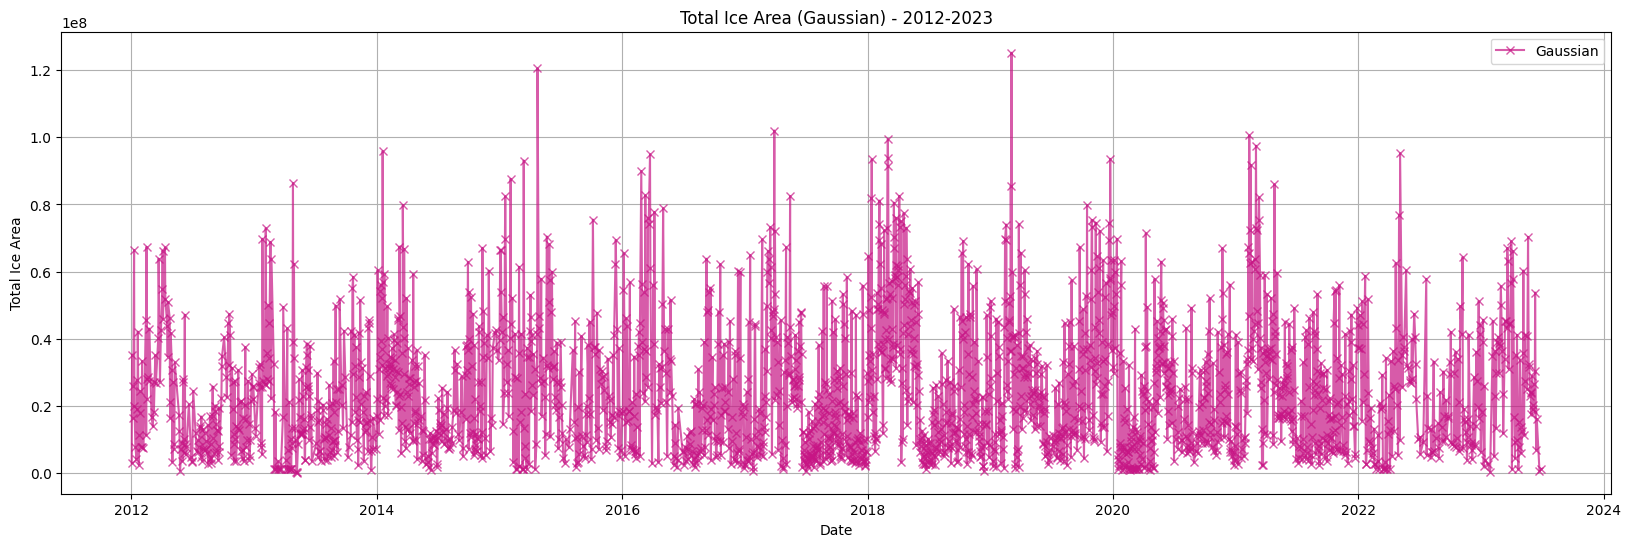

In [75]:
# Plot the results
plt.figure(figsize=(20, 6))
plt.plot(iara['date'], iara['area'], c='mediumvioletred', marker='x', alpha=0.7, label='Gaussian')
plt.xlabel('Date')
plt.ylabel('Total Ice Area')
# start_date = datetime(2012, 1, 1)
# end_date = datetime(2012, 12, 31) #(2015, 4, 30) 
# plt.xlim(start_date, end_date)
# plt.ylim(0,1.3e6)
plt.title('Total Ice Area (Gaussian) - 2012-2023')
plt.legend()
plt.grid()
# plt.savefig("C:/Users/jullian.williams/Desktop/plots/2012_2023/TICEGS_12_23.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.show()

C:\Users\jullian.williams\AppData\Local\Temp\ipykernel_12156\1170762383.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


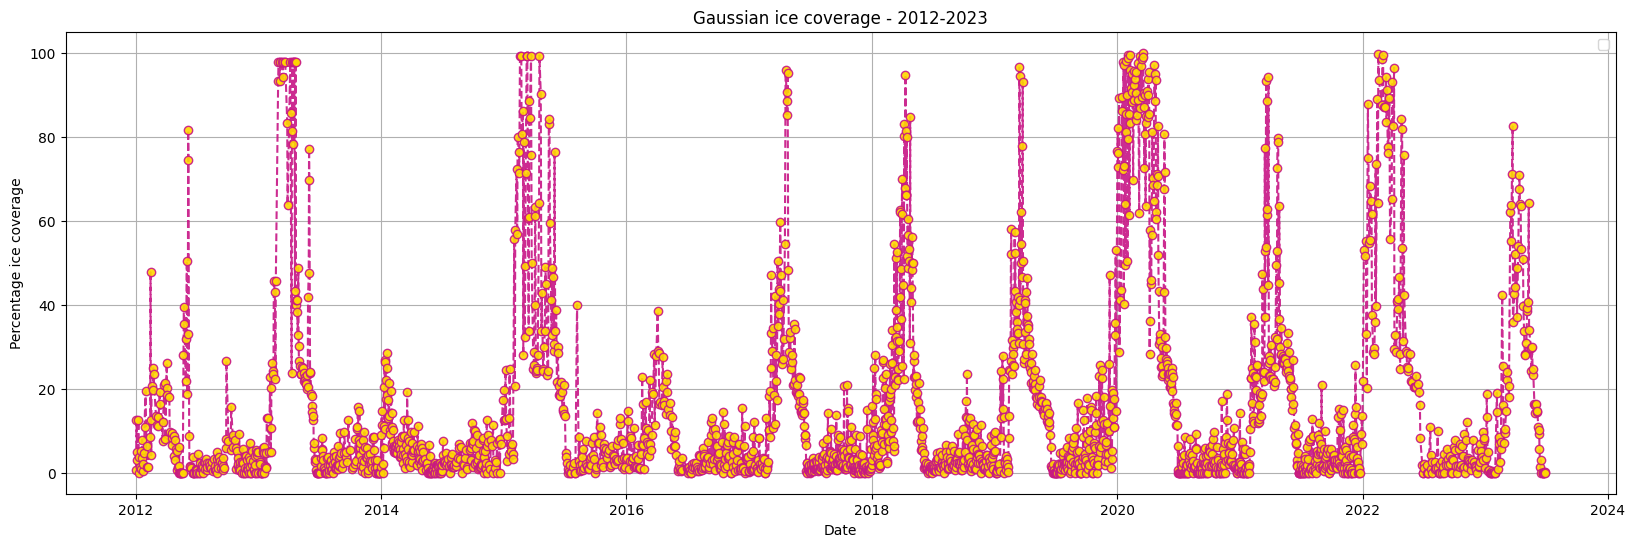

In [99]:
# Plot the results
plt.figure(figsize=(20, 6))
plt.plot(mx_['date'], mx_['perc'], c='mediumvioletred', linestyle='--', marker='o',markerfacecolor='gold', alpha=0.9)
plt.xlabel('Date')
plt.ylabel('Percentage ice coverage')
# start_date = datetime(2012, 1, 1)
# end_date = datetime(2016, 12, 31) #(2015, 4, 30) 
# plt.xlim(start_date, end_date)
# plt.ylim(0,1.3e6)
plt.title('Gaussian ice coverage - 2012-2023')
plt.legend()
plt.grid()
# plt.savefig("C:/Users/jullian.williams/Desktop/plots/2012_2023/GAUScov2.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.show()

#### Linear regression

In [71]:
y = mx['area_y'].to_numpy()
stlist = mx['julian'].to_numpy()
x = [float(i) for i in stlist]
x = np.array(x)
print(x)

[  2.   3.   5. ... 167. 175. 179.]


In [72]:
def calc_linreg_coef(x,y):
    if(np.size(x) !=np.size(y)):
        sys.exit("Length of x and y are not the same")

    #Number of observations
    n = np.size(x)

    sx = np.sum(x)
    sy = np.sum(y)
    
    sx2 = np.inner(x,x)
    sxy = np.inner(x,y)
    sy2 = np.inner(y,y)

    #Calculation of regression coefficients
    a1 = (n*sxy - sx*sy)/(n*sx2 - sx**2)
    a0 = (sy/n) - (a1*sx)/n

    r2 = ((n*sxy-sx*sy)/np.sqrt(n*sx2-sx**2)/np.sqrt(n*sy2-sy**2))**2;
          
    return (a0, a1, r2)
        

In [73]:
a0, a1, r2 = calc_linreg_coef(x,y)

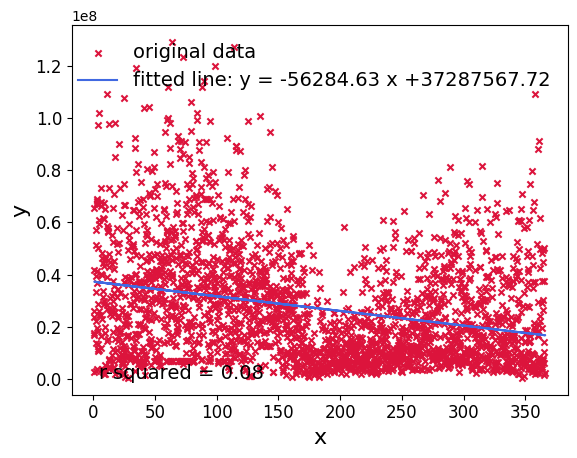

In [74]:
plt.scatter(x,y, c= 'crimson', marker='x', s=20, label = 'original data')
y_pred = a0 + a1*x
plt.plot(x,y_pred, color = 'royalblue', label = 'fitted line: y = %.2f x +%.2f'%(a1,a0)) 
plt.text(5,5,'r-squared = %.2f'%r2, fontsize = 14) 
plt.xlabel('x', fontsize = 16)
plt.ylabel('y', fontsize =16)
plt.tick_params(axis='both', which='major', labelsize = 12)
plt.legend(loc='upper right', fontsize = 14, frameon=False)
plt.show()

#### Correlations and Fourier Analysis

In [63]:
mty = (rst.groupby([rst['date'].dt.month,'value']))['area'].mean().unstack()
mty

value,0.0,1.0
date,,
1,6.231065e+06,2.721488e+07
2,7.629176e+06,3.066948e+07
3,9.619102e+06,3.333220e+07
4,7.485379e+06,2.981682e+07
5,3.107702e+06,2.875130e+07
6,1.922549e+06,1.923692e+07
7,1.870089e+05,1.158306e+07
8,5.567683e+05,1.624210e+07
9,4.372857e+05,1.965374e+07


In [64]:
icemty = (rst.groupby([rst['date'].dt.month,'value']))['area'].mean().unstack()
icemty

value,0.0,1.0
date,,
1,6.231065e+06,2.721488e+07
2,7.629176e+06,3.066948e+07
3,9.619102e+06,3.333220e+07
4,7.485379e+06,2.981682e+07
5,3.107702e+06,2.875130e+07
6,1.922549e+06,1.923692e+07
7,1.870089e+05,1.158306e+07
8,5.567683e+05,1.624210e+07
9,4.372857e+05,1.965374e+07


In [65]:
iceyrl = (rst.groupby([rst['date'].dt.year,'value']))['area'].mean().unstack()
iceyrl

value,0.0,1.0
date,,
2012,2.319792e+06,2.006472e+07
2013,3.639667e+06,1.993052e+07
2014,9.823321e+05,2.486778e+07
2015,5.919135e+06,2.782914e+07
2016,9.506633e+05,2.388237e+07
2017,2.911400e+06,1.960614e+07
2018,6.116722e+06,2.926360e+07
2019,3.621141e+06,2.860514e+07
2020,8.854192e+06,2.020646e+07


In [66]:
cormty = mty.corr()
corimty = icemty.corr()
coriyrl = iceyrl.corr()
cormty

value,0.0,1.0
value,,
0.0,1.000000,0.845202
1.0,0.845202,1.000000


In [67]:
corimty

value,0.0,1.0
value,,
0.0,1.000000,0.845202
1.0,0.845202,1.000000


In [68]:
coriyrl

value,0.0,1.0
value,,
0.0,1.000000,0.076949
1.0,0.076949,1.000000


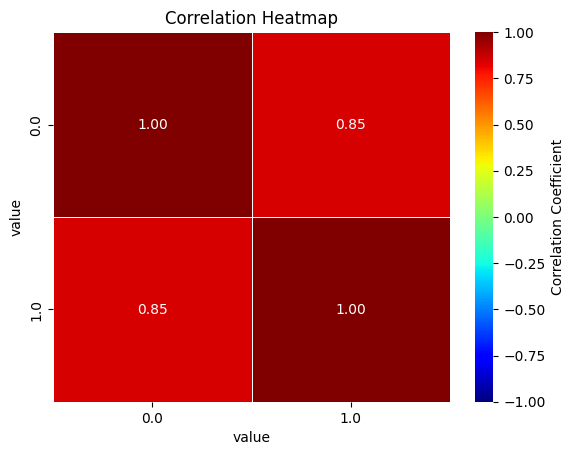

In [69]:
sns.heatmap(
    cormty, 
    annot=True, 
    fmt=".2f",  # Format for annotations:- decimal places
    cmap="jet",  # Custom color map
    linewidths=0.5,  # separation of blocks
    vmin = -1,
    vmax = 1,
    cbar_kws={'label': 'Correlation Coefficient'}  # Customize color bar
)
plt.title('Correlation Heatmap')
# plt.savefig("C:/Users/jullian.williams/Desktop/plots/2012_2023/gausscormty2.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.show()

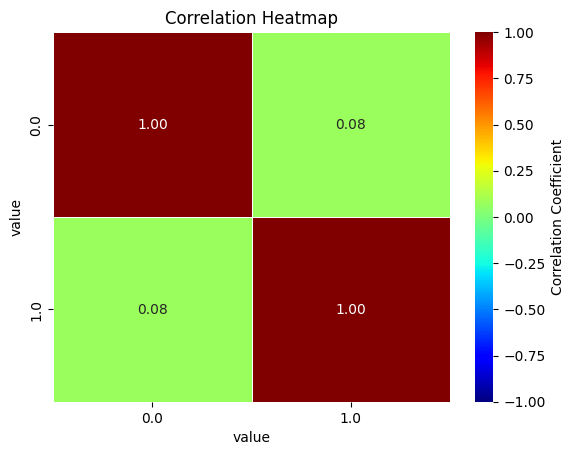

In [70]:
sns.heatmap(
    coriyrl, 
    annot=True, 
    fmt=".2f",  # Format for annotations:- decimal places
    cmap="jet",  # Custom color map
    linewidths=0.5,  # separation of blocks
    vmin = -1,
    vmax = 1,
    cbar_kws={'label': 'Correlation Coefficient'}  # Customize color bar
)
plt.title('Correlation Heatmap')
# plt.savefig("C:/Users/jullian.williams/Desktop/plots/2012_2023/gausscoriyrl2.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.show()

In [93]:
vt = (rs2bin.groupby([rs2bin['date'].dt.year,'value']))['area'].mean().unstack()

In [94]:
vt1 = vt[1]
vt1 = vt1.to_numpy()
vt1

array([ 209155.85295357,  681628.19164668,  149687.36859319,
        921364.64422495,  195630.38588265,  315873.80666981,
        375420.38926442,  488653.77066593, 1478879.12940974,
        454117.18530321, 1185551.05579133, 1489989.82317771])

In [95]:
vtft = fft(vt1)
vtft

array([ 7945951.60358319      -0.j        ,
         848034.96637117+2031733.61808216j,
        -807706.76106856 +336188.1269674j ,
         173006.55459703+1448389.0544489j ,
       -1032888.69417235 +764671.61356242j,
       -1519835.12990074-1985086.94039848j,
        -757303.2397934       -0.j        ,
       -1519835.12990074+1985086.94039848j,
       -1032888.69417235 -764671.61356242j,
         173006.55459703-1448389.0544489j ,
        -807706.76106856 -336188.1269674j ,
         848034.96637117-2031733.61808216j])

In [96]:
N = len(vtft)
n=np.arange(N)
sr=1/31556952 #placed in terms of seconds in year instead of # of years since hertz is in seconds but the plot looks virtually no different when run all the way through to the reconstruction plot
T = N/sr
freq = n/T

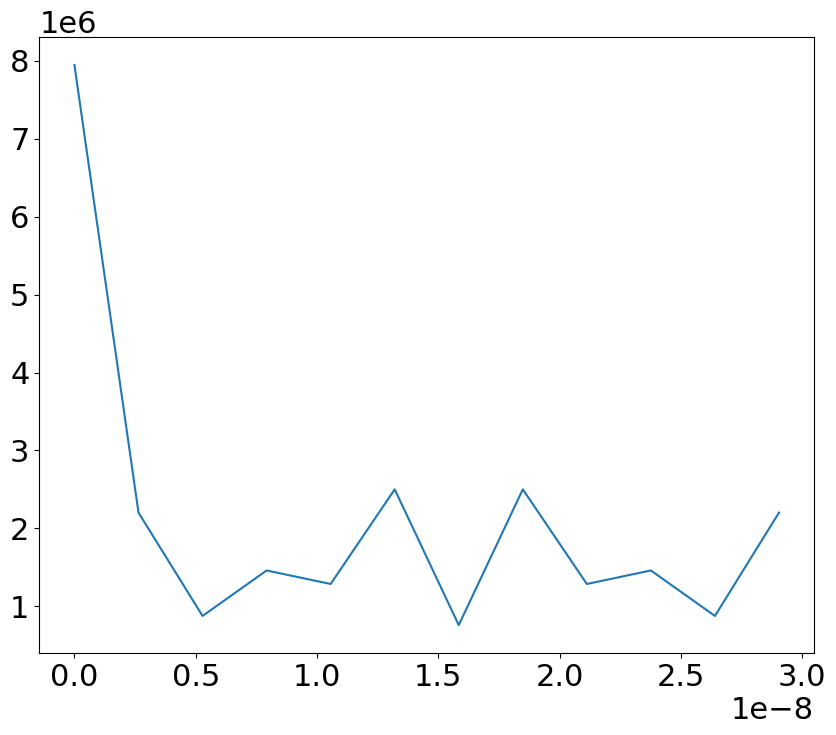

In [97]:
plt.figure(figsize=(10,8))
plt.plot(freq,np.abs(vtft)) #plot power spectrum as well

Text(0, 0.5, 'FFT amplitude')

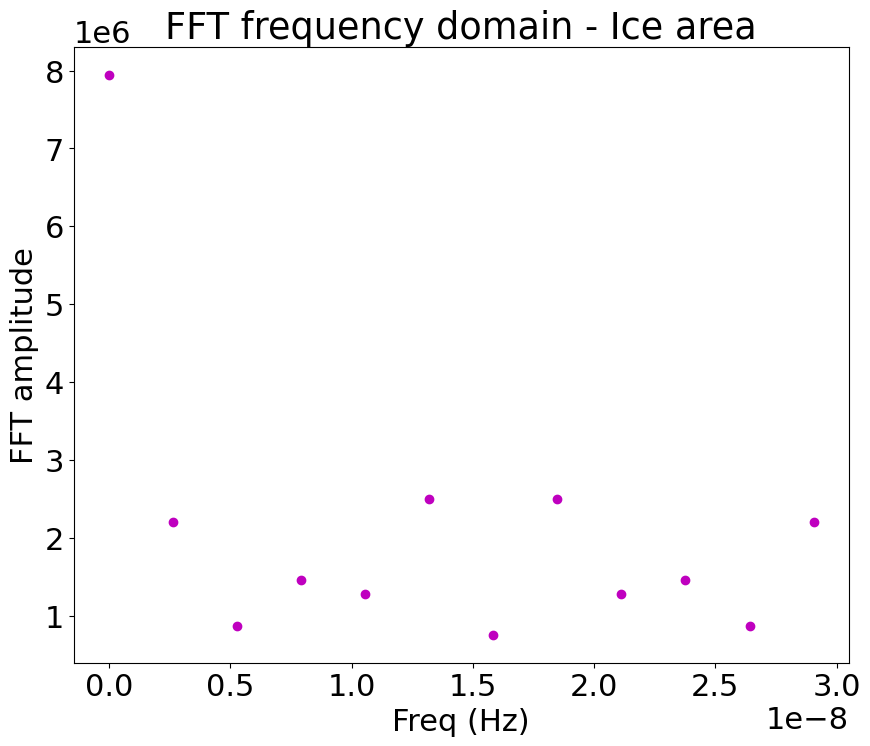

In [98]:
plt.figure(figsize=(10,8))
plt.plot(freq,np.abs(vtft),'mo') #plot power spectrum as well
plt.xlabel('Freq (Hz)')
plt.title('FFT frequency domain - Ice area')
plt.ylabel('FFT amplitude')

C:\Users\jullian.williams\AppData\Local\Temp\ipykernel_15592\511579271.py:11: RuntimeWarning: divide by zero encountered in divide
  np.allclose(peak_freq, 1./freq)


[]

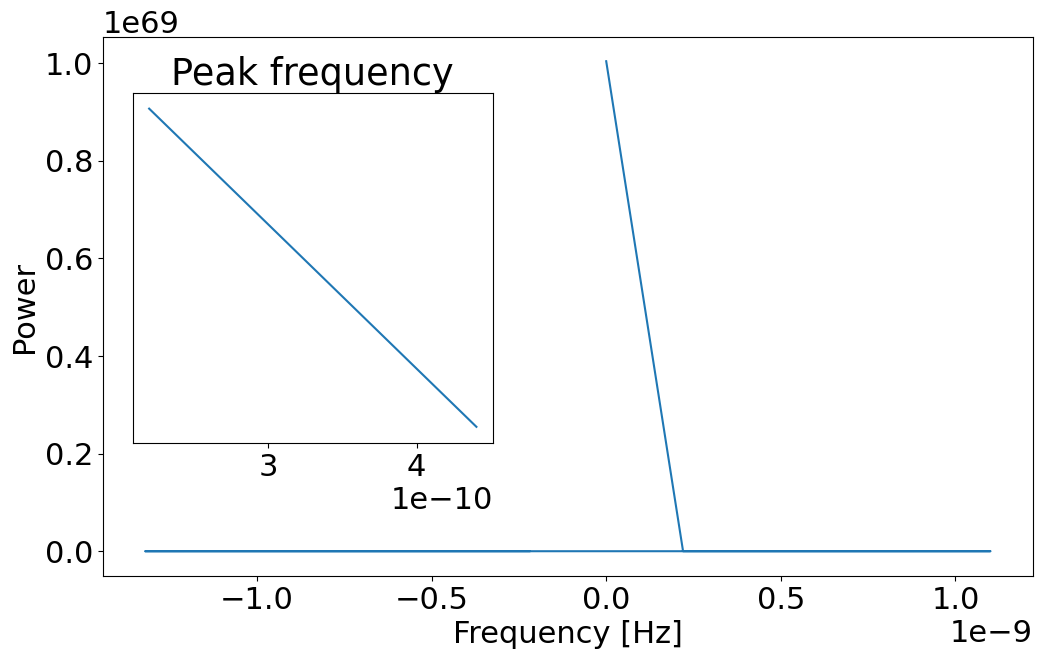

In [99]:
power = np.abs(vtft)**10
sample_freq = fftpack.fftfreq(vt1.size, d=T)
plt.figure(figsize=(12,7))
plt.plot(sample_freq, power)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')

pos_mask = np.where(sample_freq > 0)
freqs = sample_freq[pos_mask]
peak_freq = freqs[power[pos_mask].argmax()]
np.allclose(peak_freq, 1./freq)
axes = plt.axes([0.15, 0.3, 0.3, 0.5])
plt.title('Peak frequency')
plt.plot(freqs[:2], power[:2])
plt.setp(axes, yticks=[])

C:\Users\jullian.williams\.conda\envs\geospatial\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\jullian.williams\.conda\envs\geospatial\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


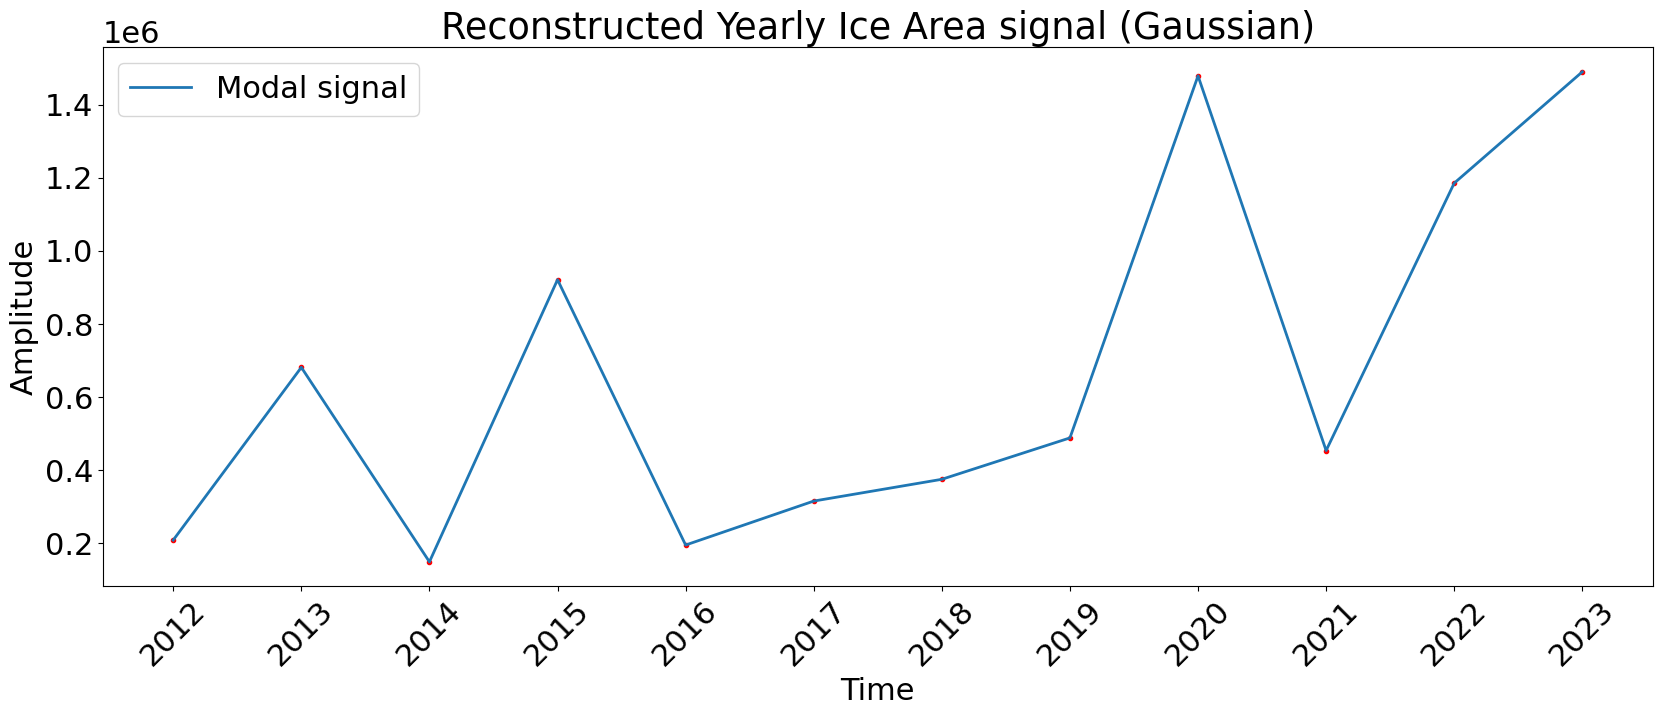

In [100]:
high_freq_fft = vtft.copy()
high_freq_fft[20::] = 0
filtered_sig = fftpack.ifft(high_freq_fft)

plt.figure(figsize=(20,7))
plt.plot(n, vt1, 'r.')
plt.plot(n, filtered_sig, linewidth=2, label= 'Modal signal')
plt.xticks(ticks=[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0], labels=['2012', '2013', '2014','2015', '2016', '2017', '2018', '2019','2020','2021','2022','2023'], rotation=45)
plt.yticks()
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Reconstructed Yearly Ice Area signal (Gaussian)')
# plt.savefig("C:/Users/jullian.williams/Desktop/plots/2012_2023/RECONgauss2_.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.legend(loc='best')

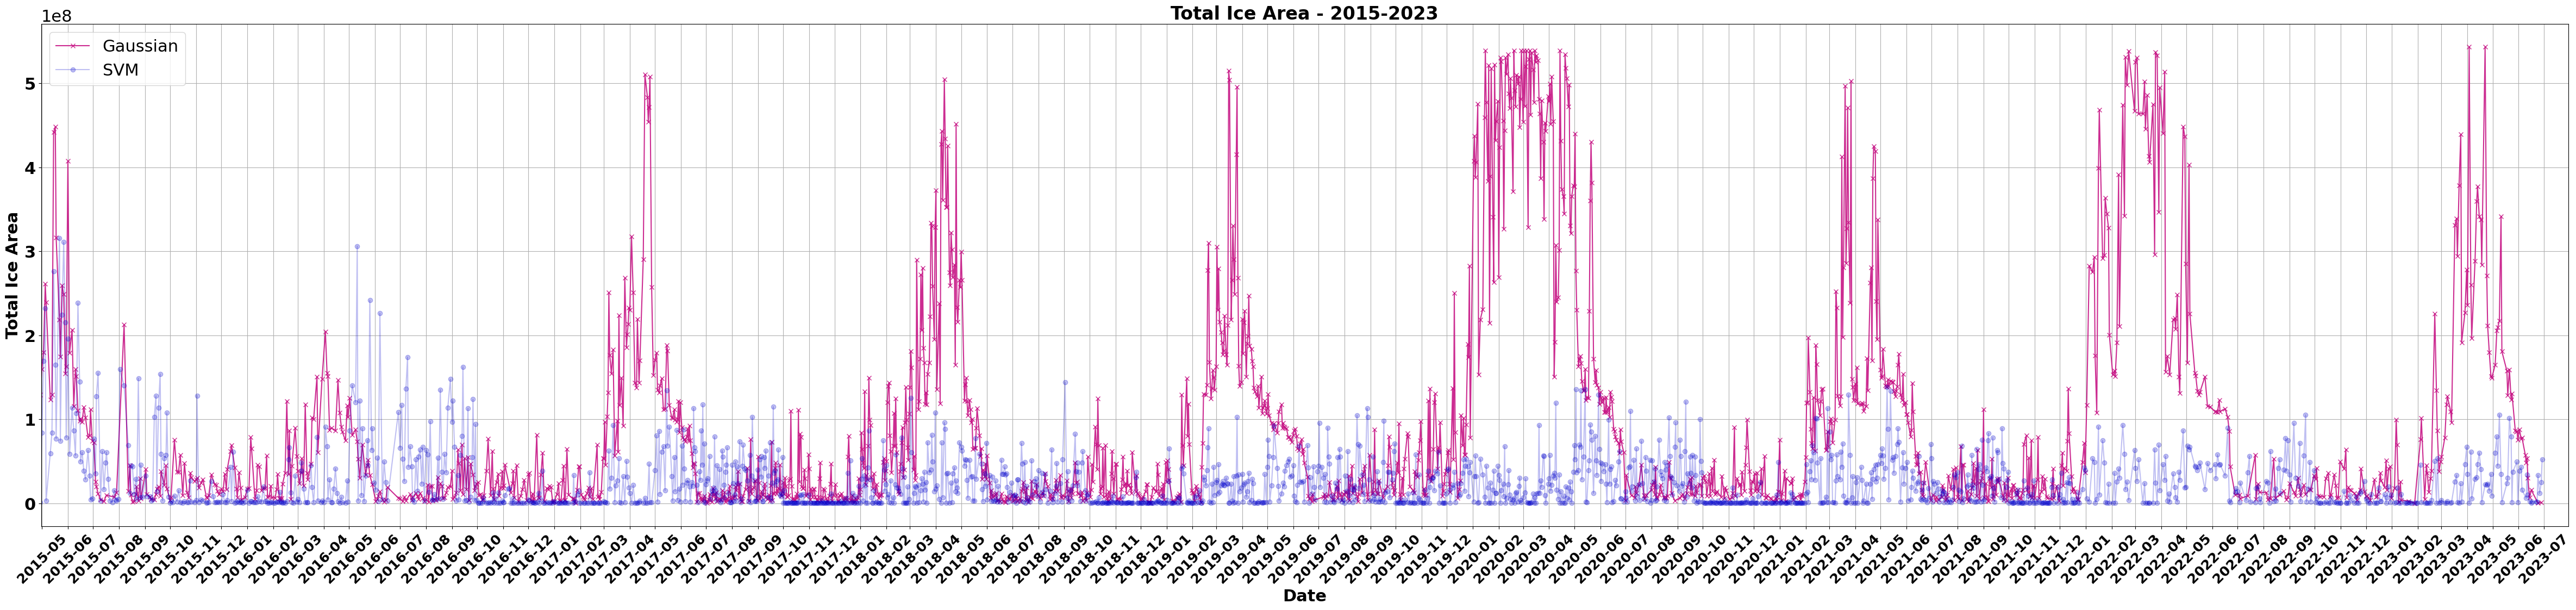

In [69]:
# Plot the results
plt.figure(figsize=(60, 12))
plt.rcParams.update({'font.size': 22})
plt.plot(iara['date'], iara['area'], c='mediumvioletred', marker='x', alpha=0.9, label='Gaussian')
plt.plot(iceara['date'], iceara['area'], c='mediumblue', marker='o', alpha=0.25, label='SVM')
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Total Ice Area',fontweight='bold')
start_date = datetime(2015, 4, 30)
end_date = datetime(2023, 7, 30)
plt.xlim(start_date, end_date)
# plt.ylim(0,1.8e8)
dtFmt = mdates.DateFormatter('%Y-%m') # define the formatting
plt.gca().xaxis.set_major_formatter(dtFmt) 
# show every 12th tick on x axes
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45, fontweight='bold',  fontsize='small')
plt.yticks(fontweight='bold')
plt.title('Total Ice Area - 2015-2023', fontweight='bold', fontsize=24)
plt.legend()
plt.grid()
# plt.savefig("C:/Users/jullian.williams/Desktop/plots/plot1523.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.show()

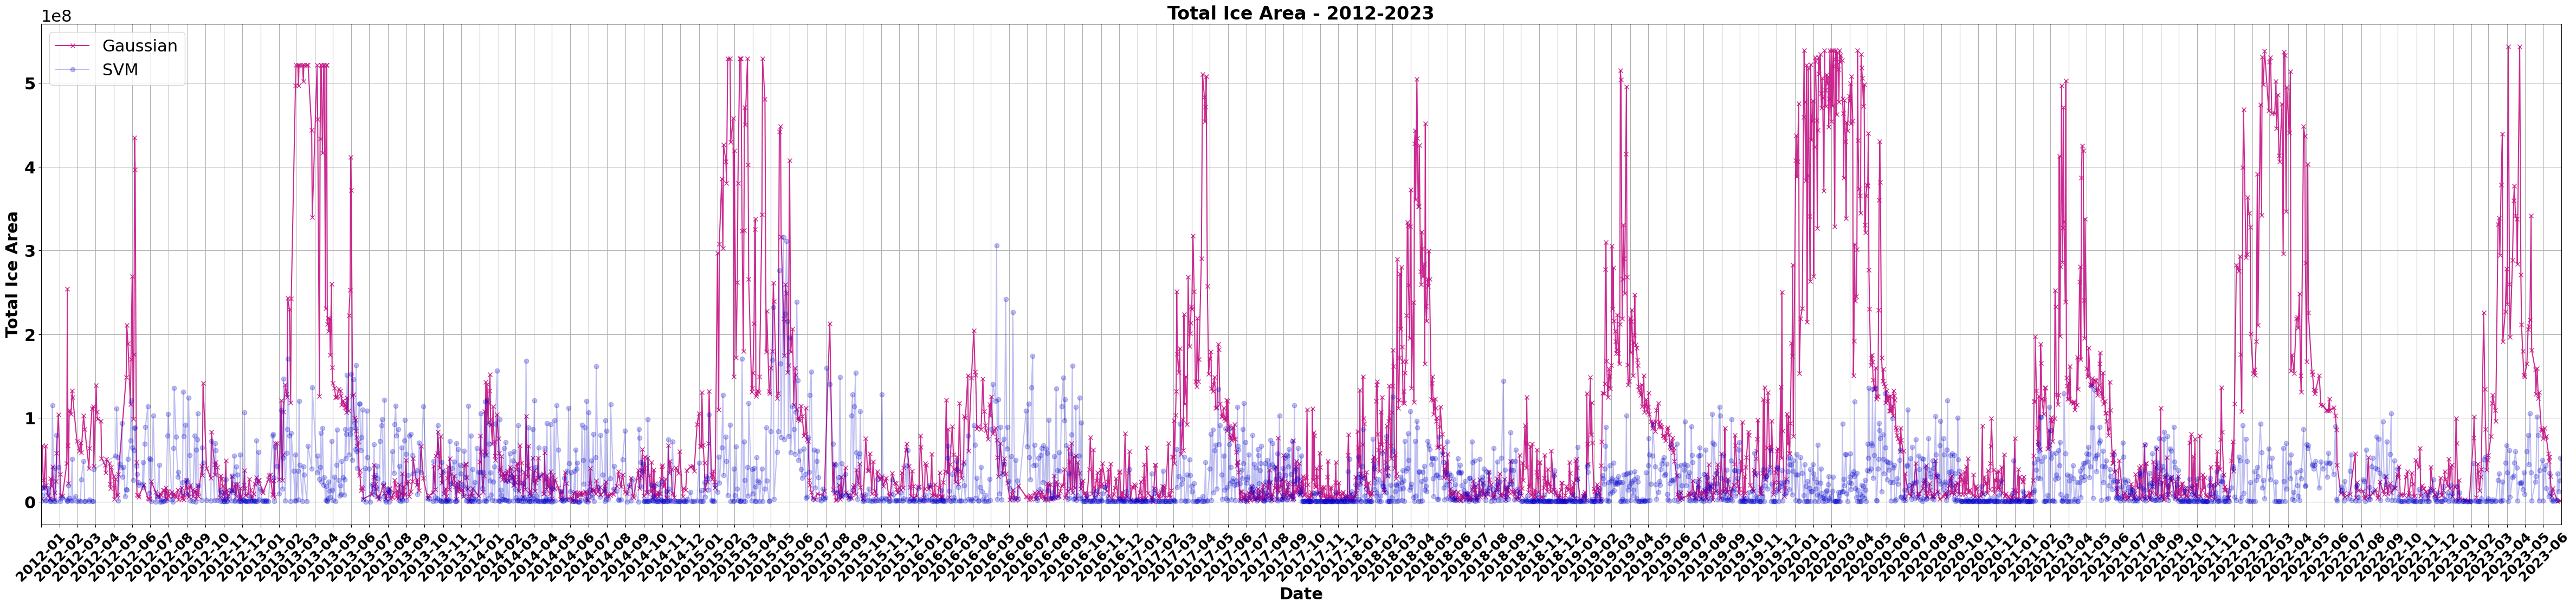

In [71]:
# Plot the results
plt.figure(figsize=(60, 12))
plt.rcParams.update({'font.size': 22})
plt.plot(iara['date'], iara['area'], c='mediumvioletred', marker='x', alpha=0.9, label='Gaussian')
plt.plot(iceara['date'], iceara['area'], c='mediumblue', marker='o', alpha=0.25, label='SVM')
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Total Ice Area',fontweight='bold')
start_date = datetime(2012, 1, 1)
end_date = datetime(2023, 6, 30)
plt.xlim(start_date, end_date)
# plt.ylim(0,1.8e8)
dtFmt = mdates.DateFormatter('%Y-%m') # define the formatting
plt.gca().xaxis.set_major_formatter(dtFmt) 
# show every 12th tick on x axes
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45, fontweight='bold',  fontsize='small')
plt.yticks(fontweight='bold')
plt.title('Total Ice Area - 2012-2023', fontweight='bold', fontsize=24)
plt.legend()
plt.grid()
# plt.savefig("C:/Users/jullian.williams/Desktop/plots/2012_2023/plot1223x.png", bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.show()

# Principal Components

### Comparing ice area from SVM and Gaussian methods for 2012 - 2023

In [121]:
iara.head(2)

,date,value,area,julian
0,2012-01-02,1.0,2950000.0,2.0
2,2012-01-03,1.0,35235000.0,3.0


In [122]:
iara.info

<bound method DataFrame.info of            date  value        area  julian
0    2012-01-02    1.0   2950000.0     2.0
2    2012-01-03    1.0  35235000.0     3.0
4    2012-01-05    1.0  26002500.0     5.0
6    2012-01-06    1.0  16237500.0     6.0
8    2012-01-09    1.0  66387500.0     9.0
...         ...    ...         ...     ...
1253 2016-02-23    1.0  44572500.0    54.0
1255 2016-02-27    1.0  89947500.0    58.0
1257 2016-02-29    1.0  56337500.0    60.0
1259 2016-03-01    1.0  39085000.0    61.0
1261 2016-03-03    1.0  23830000.0    63.0

[743 rows x 4 columns]>

In [130]:
iceara.head(2)

,date,value,area
1,2012-01-02,1.0,1140000.0
3,2012-01-03,1.0,7987500.0


In [175]:
iceara.info

<bound method DataFrame.info of            date  value        area
1    2012-01-02    1.0   1140000.0
3    2012-01-03    1.0   7987500.0
5    2012-01-05    1.0  16722500.0
7    2012-01-06    1.0  18317500.0
9    2012-01-09    1.0   1452500.0
...         ...    ...         ...
1235 2016-02-19    1.0  52227500.0
1237 2016-02-20    1.0  65177500.0
1239 2016-02-22    1.0  12925000.0
1241 2016-02-23    1.0  35187500.0
1243 2016-03-01    1.0  71212500.0

[615 rows x 3 columns]>

In [81]:
svmgs = pd.merge(iceara,iara, on='date',how='outer').fillna(0)
svmgs['julian'] = svmgs['date'].dt.strftime('%j')
print(svmgs)

           date  value_x      area_x  value_y      area_y julian
0    2012-01-02      1.0   1140000.0      1.0   2950000.0    002
1    2012-01-03      1.0   7987500.0      1.0  35235000.0    003
2    2012-01-05      1.0  16722500.0      1.0  26002500.0    005
3    2012-01-06      1.0  18317500.0      1.0  16237500.0    006
4    2012-01-09      1.0   1452500.0      1.0  66387500.0    009
...         ...      ...         ...      ...         ...    ...
2685 2023-06-23      1.0   2032500.0      0.0         0.0    174
2686 2023-06-24      1.0  33812500.0      1.0    567500.0    175
2687 2023-06-26      1.0  12077500.0      0.0         0.0    177
2688 2023-06-28      1.0  25240000.0      1.0   1252500.0    179
2689 2023-06-29      1.0  52542500.0      0.0         0.0    180

[2690 rows x 6 columns]


In [82]:
svmgs = svmgs.drop(['date','value_x', 'value_y'], axis=1)
print(svmgs)

          area_x      area_y julian
0      1140000.0   2950000.0    002
1      7987500.0  35235000.0    003
2     16722500.0  26002500.0    005
3     18317500.0  16237500.0    006
4      1452500.0  66387500.0    009
...          ...         ...    ...
2685   2032500.0         0.0    174
2686  33812500.0    567500.0    175
2687  12077500.0         0.0    177
2688  25240000.0   1252500.0    179
2689  52542500.0         0.0    180

[2690 rows x 3 columns]


In [83]:
pca= PCA(3)
rpca = svmgs.iloc[:, 0:3]
pca.fit(rpca)

PCA(n_components=3)

In [84]:
rpca.head(2)

,area_x,area_y,julian
0,1140000.0,2950000.0,002
1,7987500.0,35235000.0,003


In [85]:
print(pca.components_)
print(pca.explained_variance_)

[[ 9.95839445e-01  9.11251860e-02 -3.33813745e-07]
 [-9.11251860e-02  9.95839445e-01 -9.68324343e-07]
 [ 2.44186158e-07  9.94714416e-07  1.00000000e+00]]
[1.24345527e+15 3.75376121e+14 1.07414663e+04]


In [86]:
t = pca.transform(rpca)
print(t)

[[-2.53954098e+07 -1.64512524e+07 -2.03245775e+02]
 [-1.56344225e+07  1.50754444e+07 -1.68459355e+02]
 [-7.77707825e+06  5.08537823e+06 -1.73510090e+02]
 ...
 [-1.47722351e+07 -2.03856605e+07 -2.85093964e+01]
 [-1.55036413e+06 -2.03378068e+07 -2.20494162e+01]
 [ 2.55244080e+07 -2.40730411e+07 -1.56284035e+01]]


In [87]:
scaler = StandardScaler()
scaler.fit(rpca)

StandardScaler()

In [88]:
scaled_data = scaler.transform(rpca)

In [89]:
pca = PCA(n_components=3)
pca.fit(scaled_data)

PCA(n_components=3)

In [90]:
PCA(n_components=3)

PCA(n_components=3)

In [91]:
r_pca = pca.transform(scaled_data)
r_pca

array([[ 0.10871039, -0.97303882, -1.80610201],
       [ 1.22952206, -1.28019636, -0.61744697],
       [ 1.04284924, -0.91840784, -0.96276079],
       ...,
       [-0.84681053, -0.01089481, -0.80190253],
       [-0.6373007 ,  0.30465593, -0.76745368],
       [-0.30765486,  1.0049093 , -0.85893863]])

In [102]:
r_pca[0:,0],r_pca[:,1]

(array([ 0.10871039,  1.22952206,  1.04284924, ..., -0.84681053,
        -0.6373007 , -0.30765486]),
 array([-0.97303882, -1.28019636, -0.91840784, ..., -0.01089481,
         0.30465593,  1.0049093 ]))

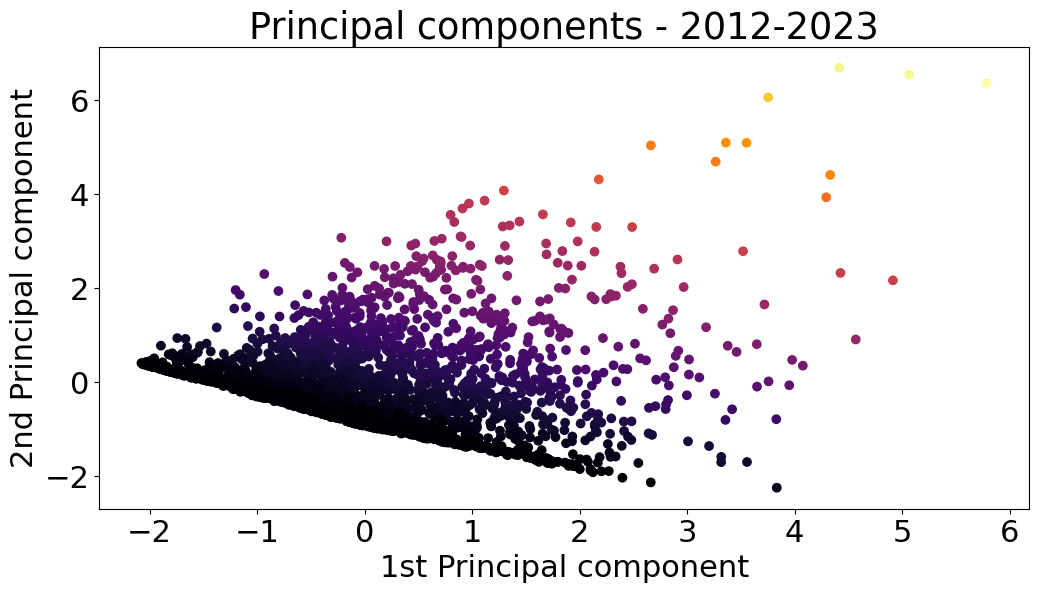

In [92]:
figx = plt.figure(figsize=(12,6))
plt.scatter(r_pca[:,0],r_pca[:,1], c = svmgs['area_x'], cmap='inferno')
plt.xlabel('1st Principal component')
plt.ylabel('2nd Principal component')
plt.title('Principal components - 2012-2023')
# plt.savefig("C:/Users/jullian.williams/Desktop/plots/2012_2023/pca2.png", bbox_inches="tight", pad_inches=0.3, transparent=True)

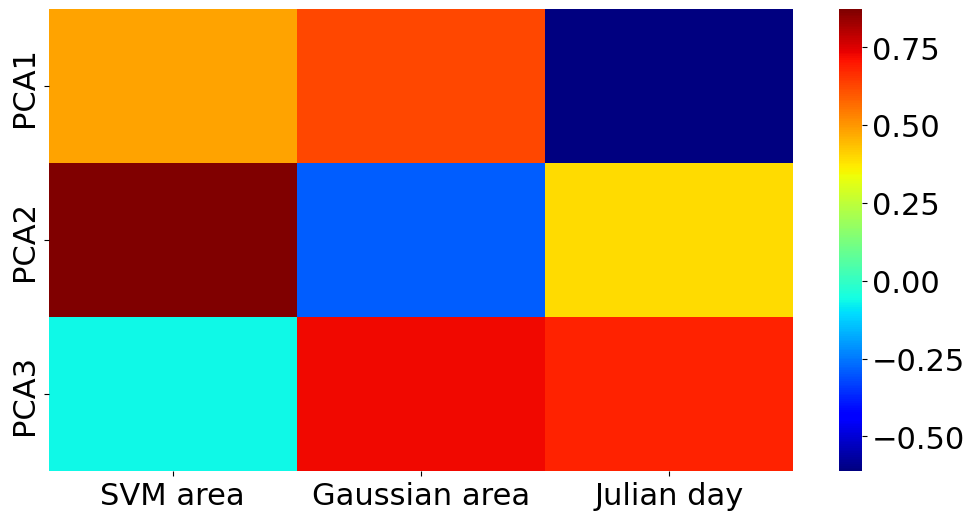

In [93]:
figx = plt.figure(figsize=(12,6))
map = pd.DataFrame(pca.components_, columns=['SVM area','Gaussian area','Julian day'])
sns.heatmap(map,cmap='jet', yticklabels=(['PCA1','PCA2','PCA3']))
# plt.savefig("C:/Users/jullian.williams/Desktop/plots/2012_2023/pcacorr2.png", bbox_inches="tight", pad_inches=0.3, transparent=True)

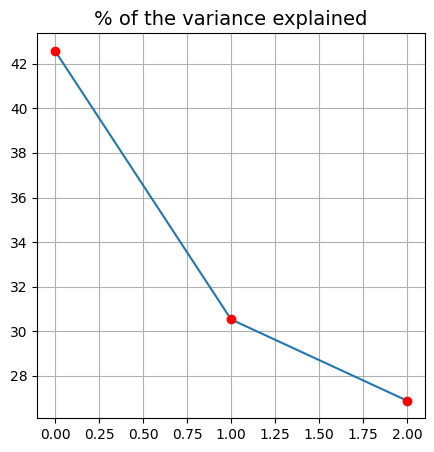

In [114]:
f, ax = plt.subplots(figsize=(5,5))
ax.plot(pca.explained_variance_ratio_[0:100]*100)
ax.plot(pca.explained_variance_ratio_[0:100]*100,'ro')
ax.set_title("% of the variance explained", fontsize=14)
ax.grid()

# Hypothesis testing

## Testing for normal data

### SVM method

In [116]:
gauss_data = rs2

In [117]:
gauss_data.head(4)

,value,geometry,date,area,perimeter,centroid,longitude,latitude
0,0.0,"POLYGON ((500275 8558875, 500275 8558825, 5003...",2012-02-03,2500.0,200.0,POINT (500300 8558850),500300.000000,8.558850e+06
1,1.0,"POLYGON ((500825 8558275, 500825 8558225, 5007...",2012-02-03,17500.0,700.0,POINT (500871.429 8558207.143),500871.428571,8.558207e+06
2,1.0,"POLYGON ((501175 8558075, 501175 8558025, 5010...",2012-02-03,70000.0,1700.0,POINT (501280.357 8557910.714),501280.357143,8.557911e+06
3,0.0,"POLYGON ((499575 8557625, 499575 8557575, 4996...",2012-02-03,2500.0,200.0,POINT (499600 8557600),499600.000000,8.557600e+06


In [118]:
#When gauss_data = rs2
gauss_data['julian'] = gauss_data['date'].dt.strftime('%j')
gauss_data['julian'] = gauss_data['julian'].to_numpy()
gauss_data['julian'] = [float(i) for i in gauss_data['julian']]
gauss_data['julian'] = np.array(gauss_data['julian'])
print(gauss_data['julian'])

0           34.0
1           34.0
2           34.0
3           34.0
4           34.0
           ...  
5352234    180.0
5352235    180.0
5352236    180.0
5352237    180.0
5352238    180.0
Name: julian, Length: 5345034, dtype: float64


In [119]:
gauss_data = gauss_data.drop(['value','perimeter','longitude','latitude','geometry','centroid','date','julian'], axis=1)
print(gauss_data)

             area
0          2500.0
1         17500.0
2         70000.0
3          2500.0
4          2500.0
...           ...
5352234    2500.0
5352235   60000.0
5352236  967500.0
5352237   17500.0
5352238   10000.0

[5345034 rows x 1 columns]


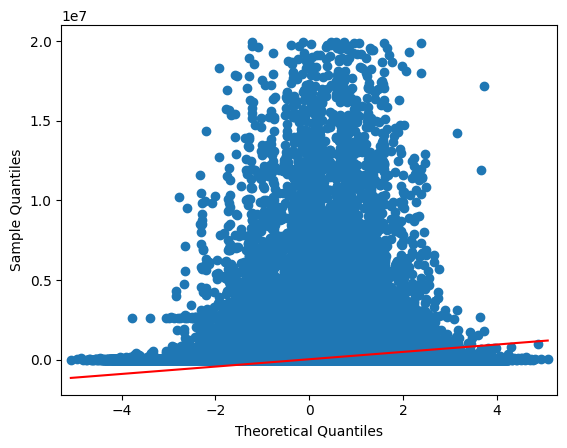

In [120]:
qqplot_data=qqplot(gauss_data, line='s').gca().lines #data is not normal. at all. test it another way. #line is: "r", "q", "45" or "s"

In [121]:
gd = gauss_data['area']
gd

0            2500.0
1           17500.0
2           70000.0
3            2500.0
4            2500.0
             ...   
5352234      2500.0
5352235     60000.0
5352236    967500.0
5352237     17500.0
5352238     10000.0
Name: area, Length: 5345034, dtype: float64

In [81]:
np.mean(gd),np.std(gd),np.min(gd),np.max(gd)

(17152.78272387316, 182154.19766844567, 2500.0, 19960000.0)

In [122]:
stat,p = normaltest(gd)

In [123]:
print(f"Statistic: {stat}")
print(f"P-value: {p}")
if p < 0.05:
    print("The data does not follow a normal distribution (reject null hypothesis).")
else:
    print("The data follows a normal distribution (fail to reject null hypothesis).")

Statistic: 16124655.47423628
P-value: 0.0
The data does not follow a normal distribution (reject null hypothesis).


### Gaussian method

In [111]:
gauss_data = rs2bin

In [86]:
gauss_data = iara

In [107]:
gauss_data.head(4)

,value,geometry,date,area,perimeter,centroid,longitude,latitude,julian
0,1.0,"POLYGON ((499625 8557925, 499625 8557875, 4995...",2012-01-02,37500.0,900.0,POINT (499626.667 8557783.333),499626.666667,8.557783e+06,2.0
1,1.0,"POLYGON ((522875 8557375, 522875 8557325, 5228...",2012-01-02,15000.0,700.0,POINT (522850 8557275),522850.000000,8.557275e+06,2.0
2,1.0,"POLYGON ((498975 8556975, 498975 8556825, 4990...",2012-01-02,12500.0,500.0,POINT (499020 8556890),499020.000000,8.556890e+06,2.0
3,1.0,"POLYGON ((523075 8556725, 523075 8556675, 5231...",2012-01-02,2500.0,200.0,POINT (523100 8556700),523100.000000,8.556700e+06,2.0


In [112]:
#When gauss_data = rs2bin
gauss_data['julian'] = gauss_data['date'].dt.strftime('%j')
gauss_data['julian'] = gauss_data['julian'].to_numpy()
gauss_data['julian'] = [float(i) for i in gauss_data['julian']]
gauss_data['julian'] = np.array(gauss_data['julian'])
print(gauss_data['julian'])

0          2.0
1          2.0
2          2.0
3          2.0
4          2.0
          ... 
146201    63.0
146202    63.0
146203    63.0
146205    63.0
146206    63.0
Name: julian, Length: 145022, dtype: float64


In [ ]:
#When gauss_data = iara
gauss_data['julian'] = gauss_data['date'].dt.strftime('%j')
gauss_data['julian'] = gauss_data['julian'].to_numpy()
gauss_data['julian'] = [float(i) for i in gauss_data['julian']]
gauss_data['julian'] = np.array(gauss_data['julian'])
print(gauss_data['julian'])

In [113]:
#When gauss_data = rs2bin
gauss_data = gauss_data.drop(['value','perimeter','longitude','latitude','geometry','centroid','date','julian'], axis=1)
print(gauss_data)

             area
0         37500.0
1         15000.0
2         12500.0
3          2500.0
4          2500.0
...           ...
146201    40000.0
146202  2700000.0
146203    30000.0
146205     5000.0
146206    40000.0

[145022 rows x 1 columns]


In [89]:
#When gauss_data = iara
gauss_data = gauss_data.drop(['value','date'], axis=1)
print(gauss_data)

            area  julian
0      2950000.0     2.0
2     35235000.0     3.0
4     26002500.0     5.0
6     16237500.0     6.0
8     66387500.0     9.0
...          ...     ...
1253  44572500.0    54.0
1255  89947500.0    58.0
1257  56337500.0    60.0
1259  39085000.0    61.0
1261  23830000.0    63.0

[743 rows x 2 columns]


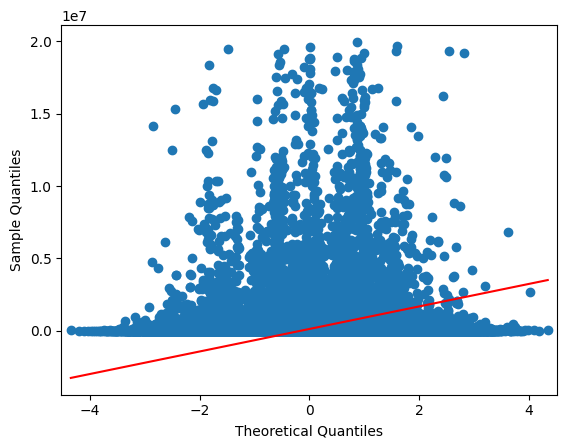

In [119]:
qqplot_data=qqplot(gauss_data, line='s').gca().lines #data is not normal. at all. test it another way. #line is: "r", "q", "45" or "s"

In [124]:
gd = gauss_data['area']
gd

0            2500.0
1           17500.0
2           70000.0
3            2500.0
4            2500.0
             ...   
5352234      2500.0
5352235     60000.0
5352236    967500.0
5352237     17500.0
5352238     10000.0
Name: area, Length: 5345034, dtype: float64

In [125]:
np.mean(gd),np.std(gd),np.min(gd),np.max(gd)

(19852.391958591845, 231117.01953698392, 2500.0, 19960000.0)

In [126]:
stat,p = normaltest(gd)

In [127]:
print(f"Statistic: {stat}")
print(f"P-value: {p}")
if p < 0.05:
    print("The data does not follow a normal distribution (reject null hypothesis).")
else:
    print("The data follows a normal distribution (fail to reject null hypothesis).")

Statistic: 16124655.47423628
P-value: 0.0
The data does not follow a normal distribution (reject null hypothesis).
